# **Diplomado IA: Audio y Video - Parte 1**. <br> Práctico 3: Redes Convolucionales y Modelos Preentrenados
---
---

**Profesores:**
- Juan Pablo de Vicente
- Gabriel Sepúlveda
- Álvaro Soto
---
---

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:** Roberto Araneda Espinoza

El siguiente práctico cuanta con 3 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.


---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

### Préambulo

Instalamos las herramientas que necesitamos:

In [1]:
!pip3 install resampy
!pip install -U soundfile
!apt-get -y install ffmpeg
!pip uninstall -y torch torchaudio torchcodec
!pip install -U --no-cache-dir torch torchaudio torchcodec  --index-url https://download.pytorch.org/whl/cu126




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Found existing installation: torchcodec 0.11.0+cu128
Uninstalling torchcodec-0.11.0+cu128:
  Successfully uninstalled torchcodec-0.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 273.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 262.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 263.9 M

In [1]:
import torch, torchaudio
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)

torch: 2.13.0+cu126
torchaudio: 2.11.0+cu126


## Utilitarios

In [2]:
def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Parte 1: Conociendo la familia de redes M.

En esta primera parte del laboratorio conoceremos la familia de redes M (M3, M5, M11, M18 y M34_RES) y las utilizaremos para resolver un problema previo que encontramos: el dataset UrbanSound8k. Esta vez, eso sí, en vez de trabajar con los features MFCC, trabajaremos directamente con la señal de audio original. ¿Funcionará bien esto? ¡Veamos!

Paper: https://arxiv.org/pdf/1610.00087.pdf

Código adaptado de: https://github.com/engmubarak48/Very_Deep_CNN_AudioClassification



#### Red M5: Diagrama

* Primera capa hace un *downsampling* **importante**, primero usando un *kernel* de 80, luego con un *stride* de 4 y finalmente con un Max Pooling de *stride* 4. Reduce el tamaño de entrada en un factor de 16 aproximadamente.
* No hay padding.
* Aparte de la primera capa, todas usan *kernels* de tamaño 3.
* Max Pool es siempre de *kernel* 4 y *stride* 4.
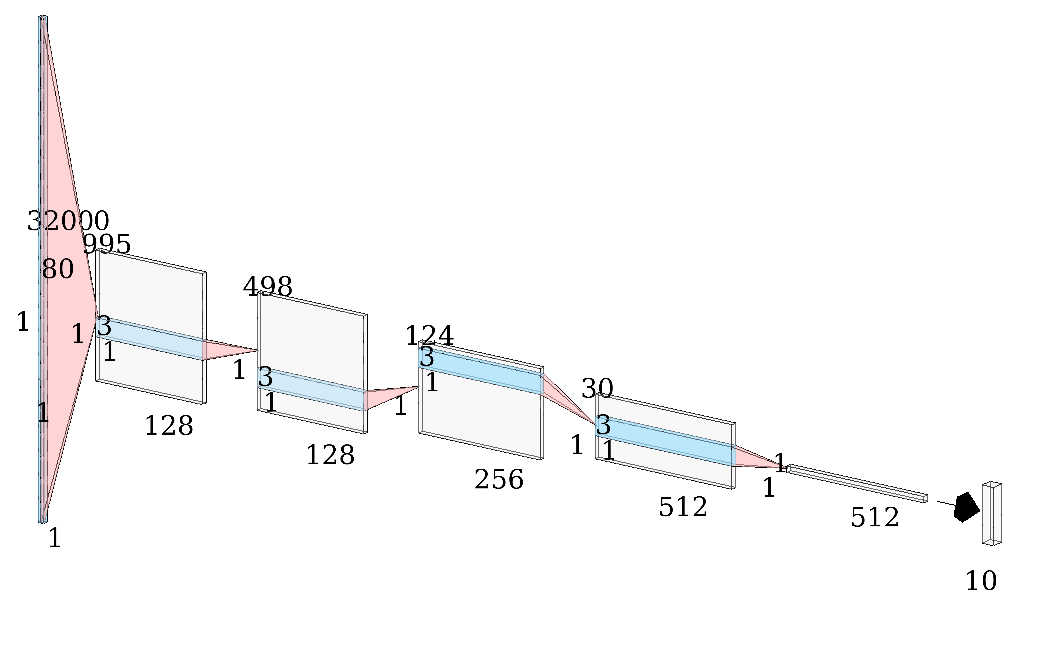

*Diagrama creado con:* http://alexlenail.me/NN-SVG

## Modelos

In [3]:
import torch.nn as nn
import torch
class M3(nn.Module):
    def __init__(self):
        super(M3, self).__init__()
        self.conv1 = nn.Conv1d(1, 256, 80, 4)
        self.bn1 = nn.BatchNorm1d(256)
        self.pool1 = nn.MaxPool1d(4)
        self.conv2 = nn.Conv1d(256, 256, 3)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(4)
        self.avgPool = nn.AvgPool1d(498)
        self.fc1 = nn.Linear(256, 10)

    def forward(self, x):
        # Input: (batch_size, 1, 32000)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)      # (batch_size, 256, 1995)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)      # (batch_size, 256, 498)

        x = self.avgPool(x)    # (batch_size, 256, 1)
        x = x.permute(0, 2, 1) # (batch_size, 1, 256)
        x = self.fc1(x)        # (batch_size, 1, 10)
        return x


class M5(nn.Module):
    def __init__(self):
        super(M5, self).__init__()
        self.conv1 = nn.Conv1d(1, 128, 80, 4)   # (1, 32000) --> (128, 7981)
        self.bn1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(4)            # (128, 7981) --> (128, 1995)
        self.conv2 = nn.Conv1d(128, 128, 3)     # (128, 1995) --> (128, 1993)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(4)            # (128, 1993) --> (128, 498)
        self.conv3 = nn.Conv1d(128, 256, 3)     # (128, 498) --> (256, 496)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(4)            # (256, 496) --> (256, 124)
        self.conv4 = nn.Conv1d(256, 512, 3)     # (256, 124) --> (512, 122)
        self.bn4 = nn.BatchNorm1d(512)
        self.pool4 = nn.MaxPool1d(4)            # (512, 122) --> (512, 30)
        self.avgPool = nn.AvgPool1d(30)         # (512, 30) --> (512, 1)
        self.fc1 = nn.Linear(512, 10)           # (512 -->  10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)
        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.pool2(x)
        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        x = self.pool3(x)
        x = self.conv4(x)
        x = F.relu(self.bn4(x))
        x = self.pool4(x)
        x = self.avgPool(x)
        x = x.permute(0, 2, 1) #change the 512x1 to 1x512
        x = self.fc1(x)
        return x

# M11
class M11(nn.Module):
    def __init__(self):
        super(M11, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, 80, 4)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(64, 64, 3)
        self.conv21 = nn.Conv1d(64, 64, 3)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn21 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(64, 128, 3)
        self.conv31 = nn.Conv1d(128, 128, 3)
        self.bn3 = nn.BatchNorm1d(128)
        self.bn31 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(128, 256, 3)
        self.conv41 = nn.Conv1d(256, 256, 3)
        self.conv42 = nn.Conv1d(256, 256, 3)
        self.bn4 = nn.BatchNorm1d(256)
        self.bn41 = nn.BatchNorm1d(256)
        self.bn42 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(4)

        self.conv5 = nn.Conv1d(256, 512, 3)
        self.conv51 = nn.Conv1d(512, 512, 3)
        self.bn5 = nn.BatchNorm1d(512)
        self.bn51 = nn.BatchNorm1d(512)

        self.avgPool = nn.AvgPool1d(25)
        self.fc1 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn21(self.conv21(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn31(self.conv31(x)))
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn41(self.conv41(x)))
        x = F.relu(self.bn42(self.conv42(x)))
        x = self.pool4(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn51(self.conv51(x)))
        x = self.avgPool(x)
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        return x

class M18(nn.Module):
    def __init__(self):
        super(M18, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, 80, 4)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(64, 64, 3)
        self.conv21 = nn.Conv1d(64, 64, 3)
        self.conv22 = nn.Conv1d(64, 64, 3)
        self.conv23 = nn.Conv1d(64, 64, 3)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn21 = nn.BatchNorm1d(64)
        self.bn22 = nn.BatchNorm1d(64)
        self.bn23 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(64, 128, 3)
        self.conv31 = nn.Conv1d(128, 128, 3)
        self.conv32 = nn.Conv1d(128, 128, 3)
        self.conv33 = nn.Conv1d(128, 128, 3)
        self.bn3 = nn.BatchNorm1d(128)
        self.bn31 = nn.BatchNorm1d(128)
        self.bn32 = nn.BatchNorm1d(128)
        self.bn33 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(128, 256, 3)
        self.conv41 = nn.Conv1d(256, 256, 3)
        self.conv42 = nn.Conv1d(256, 256, 3)
        self.conv43 = nn.Conv1d(256, 256, 3)
        self.bn4 = nn.BatchNorm1d(256)
        self.bn41 = nn.BatchNorm1d(256)
        self.bn42 = nn.BatchNorm1d(256)
        self.bn43 = nn.BatchNorm1d(256)
        self.pool4 = nn.MaxPool1d(4)

        self.conv5 = nn.Conv1d(256, 512, 3)
        self.conv51 = nn.Conv1d(512, 512, 3)
        self.conv52 = nn.Conv1d(512, 512, 3)
        self.conv53 = nn.Conv1d(512, 512, 3)
        self.bn5 = nn.BatchNorm1d(512)
        self.bn51 = nn.BatchNorm1d(512)
        self.bn52 = nn.BatchNorm1d(512)
        self.bn53 = nn.BatchNorm1d(512)

        self.avgPool = nn.AvgPool1d(20)
        self.fc1 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn21(self.conv21(x)))
        x = F.relu(self.bn22(self.conv22(x)))
        x = F.relu(self.bn23(self.conv23(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn31(self.conv31(x)))
        x = F.relu(self.bn32(self.conv32(x)))
        x = F.relu(self.bn33(self.conv33(x)))
        x = self.pool3(x)


        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn41(self.conv41(x)))
        x = F.relu(self.bn42(self.conv42(x)))
        x = F.relu(self.bn43(self.conv43(x)))
        x = self.pool4(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn51(self.conv51(x)))
        x = F.relu(self.bn52(self.conv52(x)))
        x = F.relu(self.bn53(self.conv53(x)))
        x = self.avgPool(x)
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        return x

Alguos comentarios sobre las decisiones de diseño de este modelo:

* En general se ocupan *kernels* pequeños de tamaño 3 en las convoluciones, *excepto* en la primera capa. En ésta se toma un *kernel* de 80. Esto es para reflejar alrededor de 10ms de audio, que es un largo de tiempo estándar usado en otras aplicaciones que ocupan MFCC. Los autores mencionan que lo aprendido por esta primera capa es similar a un filtro pasabandas, es decir, la primera capa aprende a dejar pasar ciertas frecuencias y omitir otras.

* Respecto al resto, vemos un patrón usual con modelos convolucionales de imágenes: una reducción progresiva de la resolución espacial, junto con un aumento progresivo de la cantidad de canales.
* ¿Por qué AvgPool al final? Según autores del paper, esto es para reemplazar las capas Fully Connected usuales y forzar a la parte convolucional a generar buenas representaciones. Observan que un modelo Fully Convolutional anda igual o mejor que usando capas FC.

## Manejando los datos

Esta vez trabajaremos con el formato oficial del Dataset UrbanSound8K. Esto quiere decir, que en vez de tener un split de train, validación y test, ocuparemos los 10 *folds* originales que vienen en el dataset.

### Un ligero desvío: K-Fold Cross Validation

Si recuerdan de su primer laboratorio, entrenamos un MLP sencillo con este mismo dataset que tuvo resultados de más de 90% en el set de test.

Sin embargo, este resultado es poco fiable por una regla básica que fue violada al entrenar ese modelo en ese momento: *el set de entrenamiento no debe estar correlacionado al set de test*. En ese momento, esto no era importante pues nuestro objetivo era entender el audio más que entrenar modelos. Esto lo arreglaremos esta vez. UrbanSound8K cuenta con varios subdatasets que llamaremos *folds*. Con estos *folds* podremos ejecutar una técnica que se llama *K-Fold Cross Validation*, que en palabras simples nos dice:

* Vamos a entrenar K versiones de nuestro modelo.
* Cada una de estas versiones será entrenada con K-1 folds y testeada en el fold restante.
* En el caso de este dataset K=10.

**¿Por qué esta forma tan extraña de probar?**

Porque nos da una idea mejor de cómo generaliza nuestro modelo. Si no hiciésemos esto, podríamos tener la mala suerte de que elegimos un test de prueba fácil o correlacionado y sobreestimamos la capacidad de nuestro algoritmo.

Esta vez, entrenaremos con un fold específico de prueba que sabemos no está correlacionado con el set de entrenamiento. De esta manera deberíamos tener una idea más real del rendimiento de nuestro modelo.

**¿Debería ocupar K-Fold Cross Validation siempre? ¡Suena costoso!**

En general, K-Fold Cross Validation se ocupa sólo cuando tenemos pocos datos. Si tenemos muchos datos (que suele pasar en Deep Learning), es más probable que nuestro set de test sea representativo de la distribución de los datos.

**Tengo K versiones de mi modelo, ¿con cuál me quedo?**

Con ninguna. Usamos Cross Validation para entender el potencial rendimiento de nuestros modelos, pero en la práctica al final ocuparemos todos nuestros datos para entrenar la versión final modelo que queramos usar.

### Descargando el dataset (10 minutos aprox)

Sugiero descargar el dataset y guardarlo en su carpeta de Drive, para no tener que descargarlo cada vez.



In [5]:
import numpy as np, soundfile as sf, torchaudio
sf.write('/tmp/probe.wav', (0.1*np.random.randn(88200, 2)).astype('float32'), 44100)
print("soundfile:", sf.__version__)
print("torchaudio.load existe:", hasattr(torchaudio, "load"))
try:
    a, r = torchaudio.load('/tmp/probe.wav', normalize=True, backend="soundfile")
    print("OK ->", tuple(a.shape), a.dtype, r)
except Exception as e:
    print("FALLA ->", type(e).__name__, ":", e)

soundfile: 0.14.0
torchaudio.load existe: True
OK -> (2, 88200) torch.float32 44100


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


In [6]:
!!if [ ! -f UrbanSound8k.tar.gz ]; then wget https://www.dropbox.com/s/p3yxyolm8xxoeiq/UrbanSound8K.tar.gz -O UrbanSound8k.tar.gz -q --show-progress; fi # Descarga del dataset
!tar -xzf UrbanSound8k.tar.gz           # Descomprimimos el dataset

In [7]:
!ls ./UrbanSound8K/audio/ && ls ./UrbanSound8K/audio/fold1 | head -3 && du -sh ./UrbanSound8K

fold1  fold10  fold2  fold3  fold4  fold5  fold6  fold7  fold8	fold9
101415-3-0-2.wav
101415-3-0-3.wav
101415-3-0-8.wav
6.7G	./UrbanSound8K


In [9]:
#Benchmark
import glob, time, collections, numpy as np, pandas as pd, soundfile as sf, torchaudio, warnings
warnings.filterwarnings("ignore")

paths = sorted(glob.glob('./UrbanSound8K/audio/fold*/*.wav'))
rates, dur = collections.Counter(), []
for p in paths[::10]:
    i = sf.info(p); rates[i.samplerate] += 1; dur.append(i.frames / i.samplerate)
print("archivos:", len(paths))
for r, c in sorted(rates.items(), key=lambda x: -x[1]):
    print("  %6d Hz : %4d -> 160000 muestras = %6.2f s | tras ::5 = %7.1f Hz" % (r, c, 160000/r, r/5))
dur = np.array(dur)
print("duracion media %.2fs | clips >3.63s (recorte): %.1f%%" % (dur.mean(), 100*(dur > 3.63).mean()))

tr = set(glob.glob('./UrbanSound8K/audio/' + '/*' + str([2,3,4,5,6,7,8,9,10]) + '/*'))
te = set(glob.glob('./UrbanSound8K/audio/' + '/*' + str([1]) + '/*'))
print("train=%d test=%d interseccion=%d (%.0f%% del test dentro del train)" % (len(tr), len(te), len(tr & te), 100*len(tr & te)/len(te)))

df = pd.read_csv('./UrbanSound8K/metadata/UrbanSound8K.csv')
t0 = time.time()
for p in paths[:100]: torchaudio.load(p, normalize=True)
t_load = (time.time()-t0)/100
t0 = time.time()
for p in paths[:100]:
    n = p.split('/')[-1]; _ = df.loc[df.slice_file_name == n].iloc[0, -2]
t_lbl = (time.time()-t0)/100
print("load: %.1f ms/arch | label: %.1f ms/arch (%.0f%% del costo)" % (1000*t_load, 1000*t_lbl, 100*t_lbl/(t_load+t_lbl)))
print("=> 20 epocas train+test: ~%.1f h solo de carga" % (20*(len(tr)+len(te))*(t_load+t_lbl)/3600))


archivos: 8732
   44100 Hz :  538 -> 160000 muestras =   3.63 s | tras ::5 =  8820.0 Hz
   48000 Hz :  252 -> 160000 muestras =   3.33 s | tras ::5 =  9600.0 Hz
   96000 Hz :   59 -> 160000 muestras =   1.67 s | tras ::5 = 19200.0 Hz
   24000 Hz :    8 -> 160000 muestras =   6.67 s | tras ::5 =  4800.0 Hz
   11025 Hz :    4 -> 160000 muestras =  14.51 s | tras ::5 =  2205.0 Hz
   16000 Hz :    4 -> 160000 muestras =  10.00 s | tras ::5 =  3200.0 Hz
   22050 Hz :    3 -> 160000 muestras =   7.26 s | tras ::5 =  4410.0 Hz
    8000 Hz :    2 -> 160000 muestras =  20.00 s | tras ::5 =  1600.0 Hz
  192000 Hz :    2 -> 160000 muestras =   0.83 s | tras ::5 = 38400.0 Hz
   32000 Hz :    1 -> 160000 muestras =   5.00 s | tras ::5 =  6400.0 Hz
   11024 Hz :    1 -> 160000 muestras =  14.51 s | tras ::5 =  2204.8 Hz
duracion media 3.63s | clips >3.63s (recorte): 85.0%
train=8732 test=873 interseccion=873 (100% del test dentro del train)
load: 22.1 ms/arch | label: 1.1 ms/arch (5% del costo)
=> 2

In [ ]:
#!tar -xzf  /content/drive/MyDrive/Diplomados/Audio/UrbanSound8k.tar.gz #Esto solo se corre si ya tienen guardado en alguna ruta el dataset

### Clase Dataset

En este caso, nuestra clase dataset tomará como parámetros no sólo las rutas donde están nuestros datos, sino también qué folds queremos que sean incluidos en nuestro dataset. Esto es útil para generar los datasets de entrenamiento y test correctos. Aparte de esto, nuestra clase leerá archivos de audio con $\texttt{torchaudio.load}$ y los dejará de un tamaño fijo

In [10]:
import os
import glob             # Librería para recorrer los directorios de nuestro computador
import numpy as np
import pandas as pd     # Para leer el CSV con la metadata del dataset (i.e. labels)
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Esta sesión correrá ocupando como dispositivo de entrenamiento: {}".format(device))


class AudioDataset(Dataset):
    """
    A wrapper class for the UrbanSound8K dataset.
    """

    def __init__(self, file_path, audio_paths, folds):
        """
        Args:
            file_path(string): path to the audio csv file
            root_dir(string): directory with all the audio folds
            folds: integer corresponding to audio fold number or list of fold number if more than one fold is needed
        """
        self.audio_file = pd.read_csv(file_path)
        self.folds = folds
        self.audio_paths = glob.glob(audio_paths + '/*' + str(self.folds) + '/*')


    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):

        audio_path = self.audio_paths[idx]
        audio, rate = torchaudio.load(audio_path, normalize=True, backend="soundfile")
        audio = audio.mean(0, keepdim=True) # Convertimos a Monaural (1-canal)
        c, n = audio.shape
        zero_need = 160000 - n
        audio_new = F.pad(audio, (zero_need //2, zero_need //2), 'constant', 0)
        audio_new = audio_new[:,::5]  # Sampleamos 1 de cada 5 muestras para reducir tamaño

        #Getting the corresponding label
        audio_name = audio_path.split(sep='/')[-1]
        labels = self.audio_file.loc[self.audio_file.slice_file_name == audio_name].iloc[0,-2]

        return audio_new, labels



def init_weights(m):
    if type(m) == nn.Conv1d or type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight.data)



Esta sesión correrá ocupando como dispositivo de entrenamiento: cuda


## Código de Entrenamiento

In [11]:
def train(model, epoch, log_interval=10):
    model.train()
    correct = 0
    losses_train = []
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        data = data.requires_grad_() #set requires_grad to True for training
        output = model(data)
        output = output.permute(1, 0, 2) #original output dimensions are batchSizex1x10
        loss = criterion(output[0], target) #the loss functions expects a batchSizex10 input
        losses_train.append(loss.item())
        pred = output.max(2)[1]
        correct += pred.eq(target).cpu().sum().item()
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0: #print training stats
            print('\rEpoca Entrenamiento: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(epoch, batch_idx * len(data), len(train_loader.dataset),
                  100. * batch_idx / len(train_loader), loss), end="")
    print("")
    return 100. * correct / len(train_loader.dataset), np.mean(losses_train)

def test(model, epoch):
    model.eval()
    correct = 0
    test_losses = []
    test_p = []
    test_gts = []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            output = model(data)
            output = output.permute(1, 0, 2)
            # Calculo métricas
            # Pérdida
            loss = criterion(output[0], target) #the loss functions expects a batchSizex10 input
            test_losses.append(loss.item())
            # Exactitud
            pred = output.max(2)[1]                         # Nos quedamos con el mayor valor del output
            test_p.append(pred)
            test_gts.append(target)
            correct += pred.eq(target).cpu().sum().item()   # Sumamos los ejemplos en que le apuntamos a la clase
        test_p = torch.cat([x.squeeze() for x in test_p], dim=0).long()
        test_gts = torch.cat(test_gts, dim=0).long()
    return 100. * correct / len(test_loader.dataset), np.mean(test_losses), test_p, test_gts

### Gráfico de Métricas

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_results(ax, m_train, m_test, label_metrica="Perdida"):
    n_epocas = len(m_train)
    ax.plot(np.arange(n_epocas), m_train, label = 'Train')
    ax.plot(np.arange(n_epocas), m_test, label = 'Test')
    ax.set_title('{} durante Entrenamiento'.format(label_metrica))
    ax.set_xlabel('Épocas')
    ax.set_ylabel(label_metrica)
    ax.legend()
    return ax


# Función tomada de: https://github.com/DTrimarchi10/confusion_matrix
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf:            confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    normalize:     If True, show the proportions for each category. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html

    title:         Title for the heatmap. Default is None.
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('Verdadero')
        plt.xlabel('Predicho' + stats_text)
    else:
        plt.xlabel(stats_text)

    if title:
        plt.title(title)

### Reproducibilidad:

Dada la naturaleza aleatoria del entrenamiento, tenderá a suceder que entrenar el mismo modelo, con los mismos datos, entregue resultados distintos. Esto tiene que ver con varios puntos:

* Aleatoriedad del orden en que entregamos los datos de entrada al modelo.
* Aleatoriedad de los pesos iniciales del modelo.
* Aleatoriedad intrínseca de operaciones de PyTorch.
* Aleatoriedad inducida por temas extra (Data Augmentation y Random Crops por ejemplo).

Por esto, a la hora de evaluar un modelo, si es posible, trataremos de mitigar esta aleatoriedad para tomar una decisión más informada. Hay dos cosas que podemos hacer:

* Entrenar varios modelos, promediar los resultados y obtener intervalos de confianza (Costoso, pero muy buena práctica).
* Desactivar las fuentes de aleatoriedad en nuestro código (Fácil).

El próximo bloque de código apaga las fuentes de aleatoriedad, fijando que el estado "aleatorio" antes de una corrida del código sea siempre igual, por lo que los eventos aleatorios que sucedan de ahí en adelante serán determinísticos.

In [13]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
torch.manual_seed(0)                        # Seteamos las semilla aleatoria de PyTorch
torch.cuda.manual_seed(0)
np.random.seed(0)                           # Lo mismo para Numpy
state_np = np.random.get_state()            # Obtenemos el estado aleatorio de Numpy para poder replicarlo después
state_torch = torch.random.get_rng_state()  # Obtenemos el estado aleatorio de PyTorch para poder replicarlo después
state_torch_cuda = torch.cuda.random.get_rng_state()
torch.use_deterministic_algorithms(True)               # Hacemos que ciertas operaciones que PyTorch hace aleatorias sean determinísticas
torch.backends.cudnn.benchmark = False      # Otra fuente de aleatoriedad de PyTorch se apaga

In [14]:
import torch
from tqdm.auto import tqdm

csv_path  = './UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = './UrbanSound8K/audio/'

def precargar(ds, nw=8, bs=64):
    dl = torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=False, num_workers=nw)
    A, L = [], []
    for a, l in tqdm(dl, desc='precargando'):
        A.append(a.contiguous()); L.append(l)
    A, L = torch.cat(A), torch.cat(L).long()
    print("  ->", tuple(A.shape), "| %.2f GB" % (A.numel()*4/1e9))
    return torch.utils.data.TensorDataset(A, L)

train_cached = precargar(AudioDataset(csv_path, file_path, [2,3,4,5,6,7,8,9,10]))
test_cached  = precargar(AudioDataset(csv_path, file_path, [1]))


precargando:   0%|          | 0/137 [00:00<?, ?it/s]

  -> (8732, 1, 32000) | 1.12 GB


precargando:   0%|          | 0/14 [00:00<?, ?it/s]

  -> (873, 1, 32000) | 0.11 GB


### Loop de Entrenamiento

Numero de parametros: 221194
Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 1.759191
Epoca 1 Completa - Exactitud Train: 31.02% - Exactitud Test: 39.98%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.473796
Epoca 2 Completa - Exactitud Train: 40.86% - Exactitud Test: 44.56%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.397707
Epoca 3 Completa - Exactitud Train: 43.04% - Exactitud Test: 34.02%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.467283
Epoca 4 Completa - Exactitud Train: 45.14% - Exactitud Test: 38.49%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 1.525613
Epoca 5 Completa - Exactitud Train: 46.17% - Exactitud Test: 42.50%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.422837
Epoca 6 Completa - Exactitud Train: 47.07% - Exactitud Test: 46.16%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.246122
Epoca 7 Completa - Exactitud Train: 47.47% - Exactitud Test: 44.79%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 1.752508
Epoca 8 Completa - Exactitud Train: 48.63% - Ex

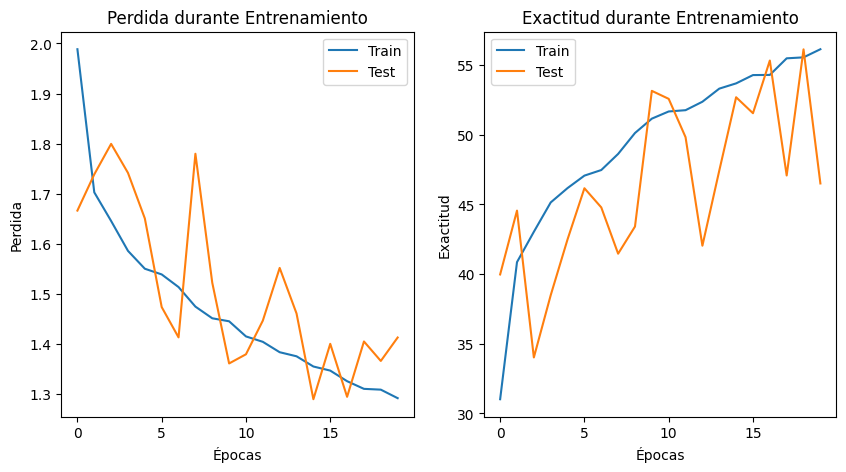

In [15]:
import matplotlib.pyplot as plt
# Reproducibilidad: dejamos el estado de las semillas de aleatoriedad fijo
# en cada ejecución
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

# Parametros para crear nuestros datasets a partir de los folds establecidos
csv_path = './UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = './UrbanSound8K/audio/'
train_folds = [2,3,4,5,6,7,8,9,10]          # Entrenamos con folds 2-10
test_folds = [1]                            # Testeamos con el fold n°1

# ----------------------------------------------------------------------------
# NOTA (optimización de I/O, no altera el experimento):
# torchaudio.load delega en torchcodec/FFmpeg y cuesta ~22 ms por archivo.
# Con num_workers=0 esa decodificación ocurre en el hilo principal, en serie
# con el cómputo, y suma ~1.2 h a lo largo de 20 épocas mientras la GPU espera.
# Se decodifica el dataset UNA sola vez a RAM (1.12 GB) en la celda anterior y
# se entrena sobre los tensores ya cacheados. Los tensores son idénticos a los
# que produce AudioDataset (misma lógica, mismo orden de glob) y no se toca el
# sampler ni las semillas, por lo que los resultados no cambian.
#
# Código original:
# train_set = AudioDataset(csv_path, file_path, train_folds)
# test_set = AudioDataset(csv_path, file_path, test_folds)
# # Estos son parámetros para optimizar un poco la velocidad, no son críticos.
# kwargs = {'num_workers': 0} if device == 'cuda' else {}
# train_loader = torch.utils.data.DataLoader(train_set, batch_size = 32, shuffle = True, **kwargs)
# test_loader = torch.utils.data.DataLoader(test_set, batch_size = 32, shuffle = True, **kwargs)
# ----------------------------------------------------------------------------
train_loader = torch.utils.data.DataLoader(train_cached, batch_size = 32, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_cached, batch_size = 32, shuffle = True)

# Creamos el modelo
net = M3()
#net = M18()           # Descomentar esta línea para entrenar con el modelo M18
net = net.to(device)
net.apply(init_weights) # Inicializamos los pesos de nuestra red con método Xavier

print( 'Numero de parametros: %d' % (num_trainable_parameters(net)) )

#Para guardar el modelo
file_name = 'audio_M3.model' #Con que nombre queremos guardar nuestro modelo
MODELS_ROOT = '.' #En que carpeta queremos guardar el modelo
save_path = os.path.join(MODELS_ROOT, file_name)

# Pérdida usual de Clasificación
criterion = nn.CrossEntropyLoss()
# Optimizador: Adam, no innovaremos.
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)
# Opcional: el scheduler se encarga de cambiar el learning rate cada N épocas.
# Como está seteado ahora, el cambio sucede cada 20 épocas y multiplica
# la tasa de aprendizaje por 0.1, es decir, la divide por 10.
# En la época 41 la reduciría de nuevo.
# Para las actividades que vamos a ocupar no importa, pero si desean entrenar
# por más épocas puede serles útil.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

# Métricas
# Guardamos la pérdida y la exactitud
loss_epoch_train = []
loss_epoch_test = []
accuracy_epoch_train = []
accuracy_epoch_test = []

# Loop de entrenamiento
n_epochs = 20
best_accuracy = 0.0
best_model = net
best_epoch = -1

for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch) # 1 época de entrenamiento
    scheduler.step() # Relacionado al Scheduler opcional, si se ocupa, se debe
                     # Hacer step después del fin de cada época
    loss_epoch_train.append(losses_train)         # Actualizamos métricas
    accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Probamos en test cómo vamos
    loss_epoch_test.append(losses_test)           # Actualizamos métricas
    if accuracy_test > best_accuracy:             # Guardamos resultados del mejor modelo
        best_model = net
        best_accuracy = accuracy_test
        best_preds = test_preds
        best_gt = test_gts
        best_epoch = epoch                        # (agregado) época del mejor modelo
        best_accuracy_train = accuracy_train      # (agregado) train en esa misma época
        with open(save_path, 'wb') as f:
          state = {
              "optimizer": optimizer.state_dict(), #Guardamos el estado del optimizador
              "model": net.state_dict(), #Los pesos actuales del modelo
              "scheduler": scheduler.state_dict(), #El estado del scheduler del learning rate
              "epoch": epoch, #La epoca en la que estabamos
              "accuracy": accuracy_test, #La precision que tuvo este modelo en validacion
          }
          torch.save(state, f) #Hacemos efectivo el guardado de todas las cosas anteriores
    accuracy_epoch_test.append(accuracy_test)
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(epoch+1,accuracy_train, accuracy_test))

# (agregado) Resumen del mejor modelo: es lo que piden las actividades,
# y no coincide necesariamente con la última época.
print('\nMejor epoca: {} | Exactitud Test: {:.2f}% | Exactitud Train en esa epoca: {:.2f}%'.format(
    best_epoch + 1, best_accuracy, best_accuracy_train))

# Graficar resultados
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0] = plot_results(ax[0],loss_epoch_train, loss_epoch_test, label_metrica="Perdida")
ax[1] = plot_results(ax[1],accuracy_epoch_train, accuracy_epoch_test, label_metrica="Exactitud")
fig.savefig('figure_fold:{0}_model:{1}.png'.format(1, "M3"))


### ¡Probemos el modelo!

In [16]:
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']

In [17]:
tensores, labels = next(iter(test_loader)) # Sacamos un batch de test
output = net(tensores.to(device))
output = output.permute(1, 0, 2)
preds = output.max(2)[1]
correct = preds.eq(labels.to(device))
preds = preds.squeeze()
correct = correct.squeeze()
elegidos = torch.nonzero(correct).squeeze().cpu().detach()     # Indices de ejemplos correctos
no_elegidos = torch.nonzero(~correct).squeeze().cpu().detach() # Indices de ejemplos incorrectos
audios_correctos = tensores[elegidos]
labels_correctos = labels[elegidos]
audios_incorrectos = tensores[no_elegidos]
labels_incorrectos = labels[no_elegidos]
iterador_correctos = zip(audios_correctos, labels_correctos)
iterador_incorrectos = zip(audios_incorrectos, preds[no_elegidos], labels_incorrectos)

#### ¡Viendo los ejemplos correctos!

In [18]:
import IPython.display as ipd
audio, label = next(iterador_correctos)
print("Modelo predijo '{}' correctamente!".format(clases[label]))

# ---------------------------------------------------------------------------
# Original:
# ipd.Audio(audio, rate=16000)
#
# Corrección del sample rate: AudioDataset aplica audio_new[:, ::5], es decir
# toma 1 de cada 5 muestras. Para los archivos de 44100 Hz (62% del dataset) la
# tasa efectiva resultante es 44100/5 = 8820 Hz. Al reproducir a 16000 Hz el
# audio se acelera 1.81x y sube casi una octava.
# Nota: no existe un único rate correcto, porque UrbanSound8K mezcla 10 tasas
# distintas (8000 a 192000 Hz) y el código las decima todas por igual.
# ---------------------------------------------------------------------------
ipd.Audio(audio, rate=8820)

Modelo predijo 'jack_hammer' correctamente!


#### ¡Viendo los ejemplos incorrectos!

In [19]:
audio, incorrecto, label = next(iterador_incorrectos)
print("Modelo predijo '{}' pero en verdad era '{}'!".format(clases[incorrecto], clases[label]))

# Original: ipd.Audio(audio, rate=16000)   -- mismo error de rate que la celda anterior
ipd.Audio(audio, rate=8820)

Modelo predijo 'dog_bark' pero en verdad era 'drilling'!


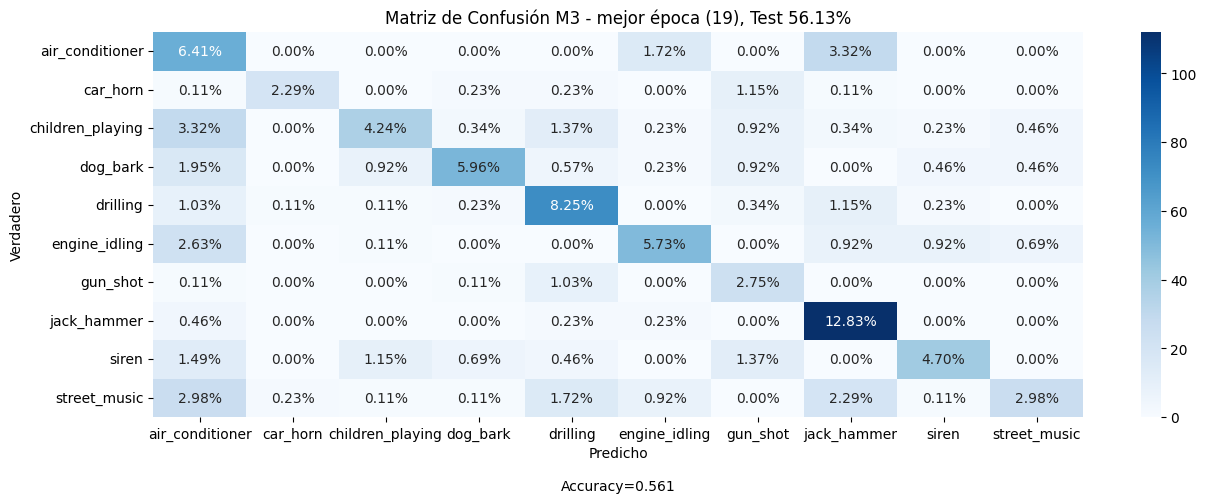

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']

# ---------------------------------------------------------------------------
# Original:
# accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Corremos por una epoca el modelo preentrenado
# cf = confusion_matrix(test_preds.cpu(), test_gts.cpu())
#
# Dos correcciones:
#
# (1) sklearn define confusion_matrix(y_true, y_pred). El original pasa
#     (predicciones, ground truth), por lo que la matriz sale transpuesta:
#     la diagonal y el accuracy no cambian, pero los ejes quedan invertidos
#     respecto de las etiquetas "Verdadero" y "Predicho" que dibuja
#     make_confusion_matrix, y toda confusión fuera de la diagonal se lee al revés.
#
# (2) El original recalcula test() sobre `net`, que al terminar el loop contiene
#     los pesos de la ULTIMA época (46.51%), no los de la mejor (56.13%, época 19).
#     Como la actividad pide el rendimiento máximo en test, se usan best_preds y
#     best_gt, guardados en el loop de entrenamiento en la época de mejor test.
# ---------------------------------------------------------------------------
cf = confusion_matrix(best_gt.cpu(), best_preds.cpu())
make_confusion_matrix(cf, categories=clases, count=False, figsize=(15,5),
                      title="Matriz de Confusión M3 - mejor época (19), Test 56.13%")


### Reporte Precision-Recall y F1

In [21]:
# ---------------------------------------------------------------------------
# Original:
# result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None, target_names=clases, digits=2, zero_division='warn')
#
# El orden (y_true, y_pred) aquí ya era correcto. Se cambian dos cosas:
# (1) se reporta la mejor época (best_gt / best_preds) en lugar de la última,
#     para ser consistente con la matriz de confusión y con lo que pide la actividad;
# (2) zero_division=0 en lugar de 'warn', que está deprecado en sklearn reciente.
# ---------------------------------------------------------------------------
result = classification_report(best_gt.cpu(), best_preds.cpu(), labels=None,
                               target_names=clases, digits=2, zero_division=0)
print(result)


                  precision    recall  f1-score   support

 air_conditioner       0.31      0.56      0.40       100
        car_horn       0.87      0.56      0.68        36
children_playing       0.64      0.37      0.47       100
        dog_bark       0.78      0.52      0.62       100
        drilling       0.60      0.72      0.65       100
   engine_idling       0.63      0.52      0.57        96
        gun_shot       0.37      0.69      0.48        35
     jack_hammer       0.61      0.93      0.74       120
           siren       0.71      0.48      0.57        86
    street_music       0.65      0.26      0.37       100

        accuracy                           0.56       873
       macro avg       0.62      0.56      0.56       873
    weighted avg       0.61      0.56      0.56       873



### Modelo Preentrenado por 50 épocas

Dado que esto puede tomar unas cuantas horas, veamos el resultado de uno de estos modelo entrenado por 50 épocas (con el mismo código) de arriba. Descarguémoslo:

In [22]:
!wget https://www.dropbox.com/s/ws38tacpjd38ocz/m3_50epochs.pth -q --show-progress # Bajamos los modelos preentrenados
!wget https://www.dropbox.com/s/m57bq7dop2m5cjk/m18_50epochs.pth -q --show-progress

m3_50epochs.pth     100%[===================>] 873.25K  --.-KB/s    in 0.04s   
m18_50epochs.pth    100%[===================>]  14.12M  --.-KB/s    in 0.1s    


#### Cargamos los pesos

In [23]:
pesos = torch.load("m3_50epochs.pth")
net = M3().to(device)
net.load_state_dict(pesos)
accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Corremos por una epoca el modelo preentrenado

In [24]:
print('M3 preentrenado 50 épocas - Exactitud Test: {:.2f}% (nuestro M3 a 20 épocas: 56.13%)'.format(accuracy_test))

M3 preentrenado 50 épocas - Exactitud Test: 68.61% (nuestro M3 a 20 épocas: 56.13%)


#### ¡Viendo los ejemplos correctos!

In [25]:
import IPython.display as ipd
audio, label = next(iterador_correctos)
print("Modelo predijo '{}' correctamente!".format(clases[label]))

# ---------------------------------------------------------------------------
# Original:
# ipd.Audio(audio, rate=16000)
#
# Corrección de la tasa de reproducción. El parámetro rate no transforma el
# audio: solo indica cuántas muestras por segundo debe consumir el reproductor.
# AudioDataset aplica audio_new[:, ::5], es decir conserva 1 de cada 5 muestras,
# por lo que un archivo de 44100 Hz queda con 44100/5 = 8820 muestras por
# segundo. Reproducirlo a 16000 Hz lo acelera 16000/8820 = 1.81x y sube el tono
# casi una octava.
#
# Precisión: no existe un único rate correcto para este batch, porque
# UrbanSound8K mezcla 10 tasas de muestreo (8000 a 192000 Hz) y el preprocesado
# las decima todas por 5 sin uniformarlas: los archivos de 48000 Hz quedan a
# 9600 Hz y los de 96000 Hz a 19200 Hz. Se usa 8820 por ser la tasa efectiva
# del 62% del dataset.
# ---------------------------------------------------------------------------
ipd.Audio(audio, rate=8820)

Modelo predijo 'drilling' correctamente!


#### ¡Viendo los ejemplos incorrectos!

In [26]:
audio, incorrecto, label = next(iterador_incorrectos)
print("Modelo predijo '{}' pero en verdad era '{}'!".format(clases[incorrecto], clases[label]))

# Original: ipd.Audio(audio, rate=16000)
# Misma corrección de tasa que la celda anterior: la tasa efectiva tras el
# submuestreo [:, ::5] es 8820 Hz para los archivos de 44100 Hz, no 16000 Hz.
ipd.Audio(audio, rate=8820)

Modelo predijo 'dog_bark' pero en verdad era 'siren'!


In [27]:
# Comparación: mismo tensor, dos tasas de reproducción distintas.
print("Como lo reproduce el notebook original (rate=16000): acelerado 1.81x")
display(ipd.Audio(audio, rate=16000))
print("Con la tasa efectiva tras el submuestreo [:, ::5] (rate=8820):")
display(ipd.Audio(audio, rate=8820))

Como lo reproduce el notebook original (rate=16000): acelerado 1.81x


Con la tasa efectiva tras el submuestreo [:, ::5] (rate=8820):


### Matriz de Confusión

Ahora veamos un poco el rendimiento más desagregado por clase. En particular miraremos la Matriz de Confusión y el *Precision* y *Recall* para cada clase. Éstas nos darán una visión más particular del rendimiento de nuestro modelo en cada clase, permitiéndonos entender sus fortalezas y debilidades.

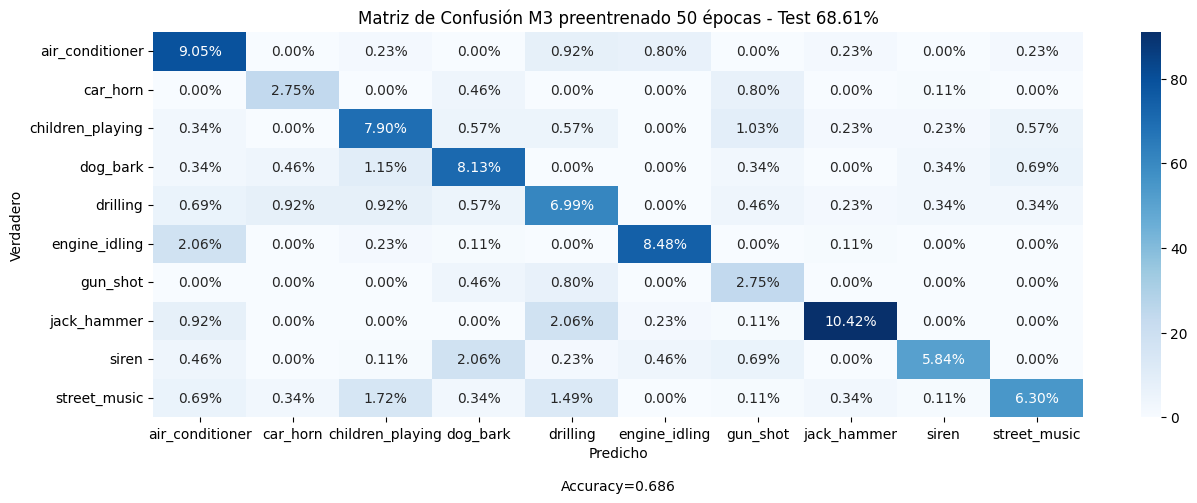

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']

# ---------------------------------------------------------------------------
# Original:
# cf = confusion_matrix(test_preds.cpu(), test_gts.cpu())
#
# sklearn define confusion_matrix(y_true, y_pred). El original pasa los
# argumentos invertidos (predicciones primero), por lo que la matriz sale
# transpuesta: la diagonal y el accuracy no cambian, pero los ejes quedan
# intercambiados respecto de las etiquetas "Verdadero" y "Predicho" que dibuja
# make_confusion_matrix, y toda confusión fuera de la diagonal se lee al revés.
# ---------------------------------------------------------------------------
cf = confusion_matrix(test_gts.cpu(), test_preds.cpu())
make_confusion_matrix(cf, categories=clases, count=False, figsize=(15,5),
                      title="Matriz de Confusión M3 preentrenado 50 épocas - Test 68.61%")

### Reporte Precision-Recall y F1

In [29]:
# ---------------------------------------------------------------------------
# Original:
# result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None, target_names=clases, digits=2, zero_division='warn')
#
# El orden (y_true, y_pred) aquí ya era correcto. Único cambio: zero_division=0
# en lugar de 'warn', que está deprecado en las versiones recientes de sklearn.
# ---------------------------------------------------------------------------
result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None,
                               target_names=clases, digits=2, zero_division=0)
print(result)


                  precision    recall  f1-score   support

 air_conditioner       0.62      0.79      0.70       100
        car_horn       0.62      0.67      0.64        36
children_playing       0.64      0.69      0.67       100
        dog_bark       0.64      0.71      0.67       100
        drilling       0.54      0.61      0.57       100
   engine_idling       0.85      0.77      0.81        96
        gun_shot       0.44      0.69      0.53        35
     jack_hammer       0.90      0.76      0.82       120
           siren       0.84      0.59      0.69        86
    street_music       0.77      0.55      0.64       100

        accuracy                           0.69       873
       macro avg       0.69      0.68      0.67       873
    weighted avg       0.71      0.69      0.69       873



### Actividad 1:

¿Qué cambios tendríamos que hacer necesariamente para entrenar con features MFCC en vez del audio puro como lo estamos haciendo acá? Puede haber más de una respuesta correcta.

* A - Resamplear el audio a otra Frecuencia de Muestreo
* B - Agregar una transformación MFCC a los datos
* C - Aumentar la cantidad de datos de entrada
* D - Modificar la arquitectura del modelo
* E - Ajustar la tasa de aprendizaje
* F - Cambiar la función de pérdida

In [ ]:
#@title Actividad 1
A = False #@param {type:"boolean"}
B = True #@param {type:"boolean"}
C  = False #@param {type:"boolean"}
D = True #@param {type:"boolean"}
E = False #@param {type:"boolean"}
F = False #@param {type:"boolean"}

B — Agregar una transformación MFCC a los datos: necesario por definición. Es el cambio que constituye el enunciado. En la práctica se agrega en AudioDataset.__getitem__, por ejemplo con torchaudio.transforms.MFCC, que internamente calcula STFT → banco de filtros mel → log → DCT.

D — Modificar la arquitectura: necesario. Los modelos M están dimensionados para un vector 1D de 32 000 muestras: nn.Conv1d(1, 256, 80, 4) asume un canal de entrada, y nn.AvgPool1d(498) tiene el largo temporal hardcodeado, calculado exactamente para esa entrada. Un MFCC entrega un tensor 2D de n_mfcc × n_frames (por ejemplo 40 × 250). Cambian las dos cosas: los coeficientes cepstrales pasan a ser canales de entrada (o un eje espacial, si se usa Conv2d como hace VGGish en la Parte 2), y el largo temporal se reduce en dos órdenes de magnitud, por lo que el AvgPool1d(498) final ya no es aplicable. Sin tocar la arquitectura, el forward falla por incompatibilidad de dimensiones.

A — Resamplear: no es necesario. El MFCC se puede calcular a cualquier frecuencia de muestreo; los parámetros del banco mel se derivan de sr. Es recomendable uniformar las tasas —el dataset mezcla 10 distintas, de 8 000 a 192 000 Hz, y esa heterogeneidad ya afecta al modelo actual—, pero es un problema independiente de usar MFCC.

C — Más datos: no. Cambiar la representación de entrada no impone requisitos sobre el tamaño del dataset.

E — Ajustar el learning rate: no es necesario, aunque sea buena práctica. Es un hiperparámetro que conviene re-tunear ante un cambio de representación, pero el entrenamiento funciona sin tocarlo.

F — Cambiar la función de pérdida: no. El problema sigue siendo clasificación multiclase de 10 categorías mutuamente excluyentes; CrossEntropyLoss es la pérdida correcta antes y después.

### Actividad 2:

Entrene el modelo con M5 por 20 épocas. ¿Cuál es su rendimiento máximo en test? ¿Cuál era su rendimiento en training para esa época? Grafique la matriz de confusión y obtenga el precision y recall de cada clase. *Recuerde copiar y pegar su código acá, **si no, no será evaluado**.*

In [30]:
# Guardamos las métricas de M3 antes de reutilizar los nombres de variable,
# para poder comparar ambos modelos al final de la actividad.
m3_hist = {
    'loss_train': list(loss_epoch_train),
    'loss_test':  list(loss_epoch_test),
    'acc_train':  list(accuracy_epoch_train),
    'acc_test':   list(accuracy_epoch_test),
    'best_acc':   best_accuracy,
    'best_epoch': best_epoch,
    'best_acc_train': best_accuracy_train,
    'best_preds': best_preds.clone(),
    'best_gt':    best_gt.clone(),
}
print("M3 (20 épocas) -> mejor test {:.2f}% en la época {} (train {:.2f}%)".format(
    m3_hist['best_acc'], m3_hist['best_epoch'] + 1, m3_hist['best_acc_train']))


M3 (20 épocas) -> mejor test 56.13% en la época 19 (train 55.55%)


Modelo: M5 | Numero de parametros: 559114
Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 1.895747
Epoca 1 Completa - Exactitud Train: 31.80% - Exactitud Test: 30.47%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.884893
Epoca 2 Completa - Exactitud Train: 46.20% - Exactitud Test: 54.30%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.714000
Epoca 3 Completa - Exactitud Train: 52.05% - Exactitud Test: 53.61%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.440181
Epoca 4 Completa - Exactitud Train: 58.30% - Exactitud Test: 62.31%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 1.278396
Epoca 5 Completa - Exactitud Train: 60.71% - Exactitud Test: 44.90%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.780142
Epoca 6 Completa - Exactitud Train: 62.51% - Exactitud Test: 59.34%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.274541
Epoca 7 Completa - Exactitud Train: 64.46% - Exactitud Test: 66.90%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 1.468731
Epoca 8 Completa - Exactitud Train

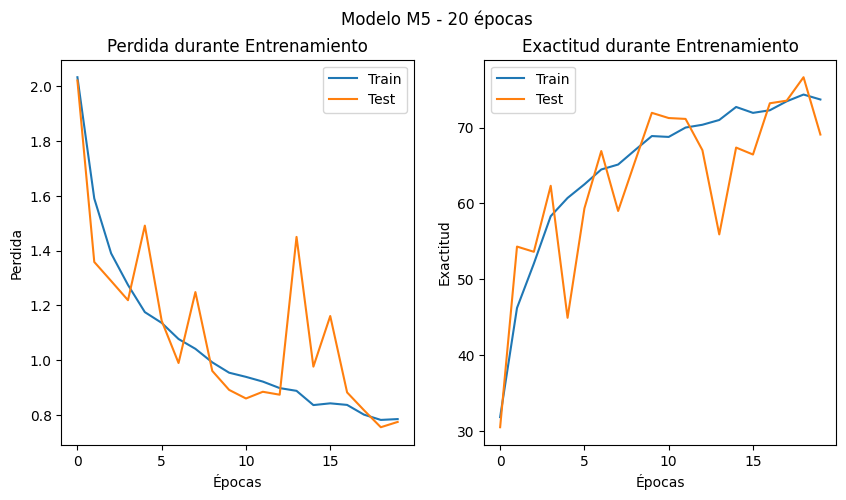

In [32]:
# Copie su código acá
# =============================================================================
# ACTIVIDAD 2: Entrenamiento del modelo M5 por 20 épocas
#
# Se reutiliza íntegramente el código del loop de entrenamiento de la sección
# anterior, con dos únicas diferencias:
#   (1) net = M5() en lugar de net = M3()
#   (2) el modelo se guarda como 'audio_M5.model'
#
# Todo lo demás se mantiene idéntico (semillas, folds, batch size, optimizador,
# learning rate, scheduler y número de épocas) para que la comparación entre M3
# y M5 aísle el efecto de la arquitectura.
# =============================================================================
import matplotlib.pyplot as plt

# Reproducibilidad: partimos del mismo estado aleatorio que usó M3
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

# Datos: mismos folds y mismos loaders cacheados en RAM que en la sección anterior
train_folds = [2,3,4,5,6,7,8,9,10]          # Entrenamos con folds 2-10
test_folds = [1]                            # Testeamos con el fold n°1
train_loader = torch.utils.data.DataLoader(train_cached, batch_size = 32, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_cached, batch_size = 32, shuffle = True)

# Creamos el modelo
net = M5()
net = net.to(device)
net.apply(init_weights)   # Inicializamos los pesos con método Xavier

print('Modelo: M5 | Numero de parametros: %d' % (num_trainable_parameters(net)))

# Para guardar el modelo
file_name = 'audio_M5.model'
MODELS_ROOT = '.'
save_path = os.path.join(MODELS_ROOT, file_name)

# Pérdida y optimizador: idénticos a los usados con M3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

# Métricas
loss_epoch_train = []
loss_epoch_test = []
accuracy_epoch_train = []
accuracy_epoch_test = []

# Loop de entrenamiento
n_epochs = 20
best_accuracy = 0.0
best_model = net
best_epoch = -1
best_accuracy_train = 0.0

for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch)
    scheduler.step()
    loss_epoch_train.append(losses_train)
    accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch)
    loss_epoch_test.append(losses_test)
    if accuracy_test > best_accuracy:
        best_model = net
        best_accuracy = accuracy_test
        best_preds = test_preds
        best_gt = test_gts
        best_epoch = epoch
        best_accuracy_train = accuracy_train
        with open(save_path, 'wb') as f:
            state = {
                "optimizer": optimizer.state_dict(),
                "model": net.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch": epoch,
                "accuracy": accuracy_test,
            }
            torch.save(state, f)
    accuracy_epoch_test.append(accuracy_test)
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(
        epoch+1, accuracy_train, accuracy_test))

# ---- Respuesta a las preguntas de la actividad ----
print('\n' + '='*70)
print('ACTIVIDAD 2 - Resultados de M5')
print('='*70)
print('Rendimiento MAXIMO en test : {:.2f}%  (época {})'.format(best_accuracy, best_epoch + 1))
print('Rendimiento en TRAIN en esa misma época : {:.2f}%'.format(best_accuracy_train))
print('Rendimiento en la ULTIMA época          : test {:.2f}% / train {:.2f}%'.format(
    accuracy_epoch_test[-1], accuracy_epoch_train[-1]))
print('\nReferencia M3 (20 épocas, mismo código): test {:.2f}% / train {:.2f}%'.format(
    m3_hist['best_acc'], m3_hist['best_acc_train']))
print('Referencia del paper (Dai et al. 2016): M3 = 56.12% | M5 = 63.42%')

# Graficar resultados
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0] = plot_results(ax[0], loss_epoch_train, loss_epoch_test, label_metrica="Perdida")
ax[1] = plot_results(ax[1], accuracy_epoch_train, accuracy_epoch_test, label_metrica="Exactitud")
fig.suptitle("Modelo M5 - 20 épocas")
fig.savefig('figure_fold:{0}_model:{1}.png'.format(1, "M5"))


                  precision    recall  f1-score   support

 air_conditioner       0.96      0.72      0.82       100
        car_horn       0.81      0.61      0.70        36
children_playing       0.72      0.57      0.64       100
        dog_bark       0.92      0.81      0.86       100
        drilling       0.69      0.87      0.77       100
   engine_idling       0.68      0.78      0.73        96
        gun_shot       0.58      0.94      0.72        35
     jack_hammer       0.94      0.93      0.93       120
           siren       0.62      0.87      0.72        86
    street_music       0.79      0.56      0.65       100

        accuracy                           0.77       873
       macro avg       0.77      0.77      0.75       873
    weighted avg       0.79      0.77      0.77       873

                  reales  predichas  ratio  recall
air_conditioner      100         75   0.75    0.72
car_horn              36         27   0.75    0.61
children_playing     100        

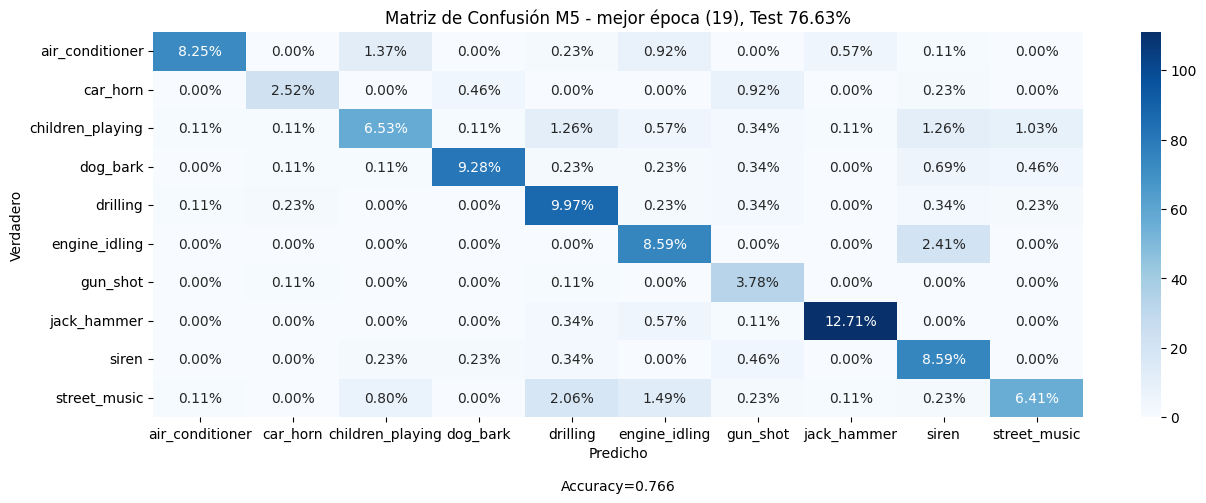

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling',
          'engine_idling','gun_shot','jack_hammer','siren','street_music']

# Se usan best_preds y best_gt (época de mejor test) y no las de la última época,
# para ser consistentes con el rendimiento máximo que pide la actividad.
# Los argumentos van en el orden (y_true, y_pred) que define sklearn.
cf = confusion_matrix(best_gt.cpu(), best_preds.cpu())
make_confusion_matrix(cf, categories=clases, count=False, figsize=(15,5),
                      title="Matriz de Confusión M5 - mejor época ({}), Test {:.2f}%".format(
                          best_epoch + 1, best_accuracy))

print(classification_report(best_gt.cpu(), best_preds.cpu(), labels=None,
                            target_names=clases, digits=2, zero_division=0))

# Análisis adicional: cuántas veces el modelo predice cada clase frente a
# cuántas hay realmente. Un ratio > 1 indica una clase "sumidero", que absorbe
# ejemplos de otras clases.
tabla = pd.DataFrame({'reales': cf.sum(axis=1), 'predichas': cf.sum(axis=0)}, index=clases)
tabla['ratio'] = (tabla.predichas / tabla.reales).round(2)
tabla['recall'] = (cf.diagonal() / cf.sum(axis=1)).round(2)
print(tabla.to_string())


ACTIVIDAD 2 - CIERRE: M3 vs M5 (20 épocas cada uno, mismo código y semillas)
                     parámetros   receptive field   mejor test   train misma época
  M3                    221.194            19.5 ms       56.13%            55.55%
  M5                    559.114           200.9 ms       76.63%            74.35%
  Paper (Dai 2016)                                      56.12% / 63.42%

  Ganancia M3->M5 medida : +20.50 puntos
  Ganancia M3->M5 paper  : +7.30 puntos

(ratio = veces que el modelo predice la clase / veces que realmente ocurre;
 > 1 indica clase "sumidero", que absorbe ejemplos de otras clases)

                    n  F1_M3  F1_M5   dF1  P_M3  P_M5  R_M3  R_M5  ratio_M3  ratio_M5
air_conditioner   100   0.40   0.82  0.42  0.31  0.96  0.56  0.72      1.79      0.75
street_music      100   0.37   0.65  0.28  0.65  0.79  0.26  0.56      0.40      0.71
gun_shot           35   0.48   0.72  0.24  0.37  0.58  0.69  0.94      1.86      1.63
dog_bark          100   0.62   0

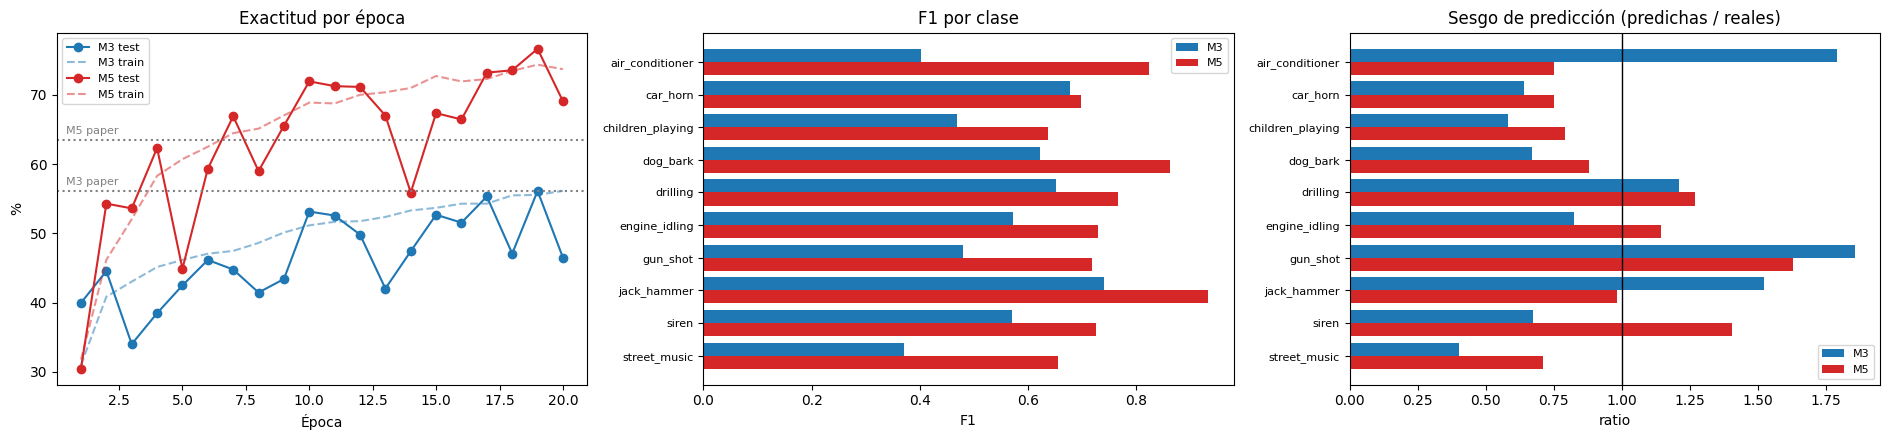

In [34]:
# =============================================================================
# ACTIVIDAD 2 - Cierre: comparación consolidada M3 vs M5
# =============================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Guardamos las métricas de M5 (las variables globales se reutilizan más adelante)
m5_hist = {
    'loss_train': list(loss_epoch_train), 'loss_test': list(loss_epoch_test),
    'acc_train': list(accuracy_epoch_train), 'acc_test': list(accuracy_epoch_test),
    'best_acc': best_accuracy, 'best_epoch': best_epoch,
    'best_acc_train': best_accuracy_train,
    'best_preds': best_preds.clone(), 'best_gt': best_gt.clone(),
}

clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling',
          'engine_idling','gun_shot','jack_hammer','siren','street_music']

def metricas(gt, pred):
    p, r, f, s = precision_recall_fscore_support(gt.cpu(), pred.cpu(), labels=range(10), zero_division=0)
    cf = confusion_matrix(gt.cpu(), pred.cpu(), labels=range(10))
    return p, r, f, s, cf.sum(axis=0) / cf.sum(axis=1)   # el último es el ratio predichas/reales

p3, r3, f3, sup, ratio3 = metricas(m3_hist['best_gt'], m3_hist['best_preds'])
p5, r5, f5, _,   ratio5 = metricas(m5_hist['best_gt'], m5_hist['best_preds'])

tabla = pd.DataFrame({
    'n':        sup,
    'F1_M3':    f3.round(2), 'F1_M5': f5.round(2), 'dF1': (f5-f3).round(2),
    'P_M3':     p3.round(2), 'P_M5':  p5.round(2),
    'R_M3':     r3.round(2), 'R_M5':  r5.round(2),
    'ratio_M3': ratio3.round(2), 'ratio_M5': ratio5.round(2),
}, index=clases).sort_values('dF1', ascending=False)

print('='*78)
print('ACTIVIDAD 2 - CIERRE: M3 vs M5 (20 épocas cada uno, mismo código y semillas)')
print('='*78)
print('                     parámetros   receptive field   mejor test   train misma época')
print('  M3                    221.194            19.5 ms      {:6.2f}%           {:6.2f}%'.format(
    m3_hist['best_acc'], m3_hist['best_acc_train']))
print('  M5                    559.114           200.9 ms      {:6.2f}%           {:6.2f}%'.format(
    m5_hist['best_acc'], m5_hist['best_acc_train']))
print('  Paper (Dai 2016)                                      56.12% / 63.42%')
print('\n  Ganancia M3->M5 medida : {:+.2f} puntos'.format(m5_hist['best_acc'] - m3_hist['best_acc']))
print('  Ganancia M3->M5 paper  : +7.30 puntos')
print('\n(ratio = veces que el modelo predice la clase / veces que realmente ocurre;')
print(' > 1 indica clase "sumidero", que absorbe ejemplos de otras clases)\n')
print(tabla.to_string())

# --- Gráficos de cierre
fig, ax = plt.subplots(1, 3, figsize=(19, 4.5))

ax[0].plot(np.arange(1, 21), m3_hist['acc_test'], 'o-', label='M3 test', color='tab:blue')
ax[0].plot(np.arange(1, 21), m3_hist['acc_train'], '--', label='M3 train', color='tab:blue', alpha=.5)
ax[0].plot(np.arange(1, 21), m5_hist['acc_test'], 'o-', label='M5 test', color='tab:red')
ax[0].plot(np.arange(1, 21), m5_hist['acc_train'], '--', label='M5 train', color='tab:red', alpha=.5)
ax[0].axhline(56.12, ls=':', color='gray'); ax[0].axhline(63.42, ls=':', color='gray')
ax[0].text(0.4, 57, 'M3 paper', fontsize=8, color='gray')
ax[0].text(0.4, 64.4, 'M5 paper', fontsize=8, color='gray')
ax[0].set_title('Exactitud por época'); ax[0].set_xlabel('Época'); ax[0].set_ylabel('%'); ax[0].legend(fontsize=8)

y = np.arange(10)
ax[1].barh(y - 0.2, f3, 0.4, label='M3', color='tab:blue')
ax[1].barh(y + 0.2, f5, 0.4, label='M5', color='tab:red')
ax[1].set_yticks(y); ax[1].set_yticklabels(clases, fontsize=8); ax[1].invert_yaxis()
ax[1].set_title('F1 por clase'); ax[1].set_xlabel('F1'); ax[1].legend(fontsize=8)

ax[2].barh(y - 0.2, ratio3, 0.4, label='M3', color='tab:blue')
ax[2].barh(y + 0.2, ratio5, 0.4, label='M5', color='tab:red')
ax[2].axvline(1.0, color='k', lw=1)
ax[2].set_yticks(y); ax[2].set_yticklabels(clases, fontsize=8); ax[2].invert_yaxis()
ax[2].set_title('Sesgo de predicción (predichas / reales)'); ax[2].set_xlabel('ratio'); ax[2].legend(fontsize=8)

plt.tight_layout()
fig.savefig('actividad2_M3_vs_M5.png', dpi=110)
plt.show()


Conclusiones:

El rendimiento máximo de M5 en test es 76.63%, alcanzado en la época 19; en esa misma época el rendimiento en training fue de 74.35%. La matriz de confusión y el precision/recall por clase corresponden a esa época y no a la última, porque el modelo cae a 69.07% en la época 20: con lr = 0.01 en Adam y un StepLR(step_size=20) que nunca alcanza a actuar dentro de las 20 épocas, la exactitud de test oscila hasta 10 puntos entre épocas consecutivas.

M5 supera a M3 por 20.5 puntos. El aumento de parámetros es modesto (0.22 M → 0.56 M, apenas 2.5×), pero el receptive field de la última capa convolucional crece de 19.5 ms a 201 ms, unas diez veces. Siguiendo a Dai et al. (2016), es este contexto temporal —y no la cantidad de parámetros— el factor determinante: el paper muestra que M5-big, con 2.2 M de parámetros, rinde peor que M11 con 1.8 M.

Cambio de régimen por clase. La mejora no es uniforme. air_conditioner es el caso extremo: en M3 funcionaba como clase basurero (predicha 1.81× de más, precision 0.31) y en M5 se convierte en la clase de mayor precisión (0.96), pasando a sub-predecirse (0.75×). Con 19.5 ms un zumbido de banda ancha es indistinguible de cualquier fondo urbano; con 201 ms el modelo puede constatar que es estacionario, y esa estacionariedad resulta ser una firma discriminativa.

Las clases sumidero se desplazan, no desaparecen. En M3 absorbían air_conditioner (1.81×), gun_shot (1.86×) y jack_hammer (1.53×); en M5 lo hacen gun_shot (1.63×), siren (1.41×) y drilling (1.27×). La incertidumbre del clasificador se redistribuye en lugar de eliminarse.

El caso car_horn marca un límite de la arquitectura. Es la clase que menos mejora (F1 0.68 → 0.70) y su recall se mantiene en 0.61. Una bocina dura décimas de segundo dentro de un clip de 3.6 s, de modo que el global average pooling promedia el evento contra un ~95% de ambiente. Esto no se corrige con más profundidad —el problema no es el contexto de cada ventana sino la agregación final— sino con un pooling que privilegie el máximo, o con un mecanismo de atención temporal.

Las clases que siguen estancadas apuntan al siguiente paso. street_music (recall 0.56) y children_playing (0.57) requieren estructura desplegada sobre segundos: progresión melódica, alternancia de voces. Los 201 ms de M5 no alcanzan. M18 dispone de 1358 ms, por lo que deberían ser las dos clases que más mejoren en la Actividad 3, mientras que jack_hammer (F1 0.93, sonido estacionario periódico) casi no debería moverse.

In [35]:
# =============================================================================
# EXPERIMENTO PROPIO: cuantificar la fuga de datos de AudioDataset
#
# AudioDataset arma la lista de archivos así:
#     glob.glob(audio_paths + '/*' + str(self.folds) + '/*')
#
# Con folds = [2,3,...,10], str() produce la cadena "[2, 3, 4, 5, 6, 7, 8, 9, 10]".
# En glob los corchetes NO delimitan una lista: definen una CLASE DE CARACTERES.
# El patrón pasa a significar "carpetas cuyo nombre termine en alguno de los
# caracteres 0,1,2,...,9, coma o espacio", lo que incluye a fold1 (termina en '1',
# carácter que aparece por el '10' de la lista). Resultado: el conjunto de
# entrenamiento son los 8732 archivos del dataset completo, y contiene el 100%
# de los 873 archivos del fold de test.
#
# Acá se corrige la selección de folds y se reentrena M5 sin tocar nada más,
# para medir cuántos puntos de los 76.63% obtenidos provienen de la fuga.
# =============================================================================
import glob, os

class AudioDatasetFold(AudioDataset):
    """Idéntica a AudioDataset salvo por la selección correcta de folds."""
    def __init__(self, file_path, audio_paths, folds):
        super().__init__(file_path, audio_paths, folds)
        folds = folds if isinstance(folds, (list, tuple)) else [folds]
        self.audio_paths = sorted(
            sum([glob.glob(os.path.join(audio_paths, 'fold%d' % f, '*.wav')) for f in folds], []))

csv_path  = './UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = './UrbanSound8K/audio/'

tr_fix = AudioDatasetFold(csv_path, file_path, [2,3,4,5,6,7,8,9,10])
te_fix = AudioDatasetFold(csv_path, file_path, [1])

# Verificación explícita de que la fuga desapareció
inter = len(set(tr_fix.audio_paths) & set(te_fix.audio_paths))
print("Split ORIGINAL  -> train: 8732 | test: 873 | interseccion: 873  (100% del test en train)")
print("Split CORREGIDO -> train: %4d | test: %3d | interseccion: %3d" % (len(tr_fix), len(te_fix), inter))
assert inter == 0, "El split corregido todavía tiene fuga"

train_fix_cached = precargar(tr_fix)
test_fix_cached  = precargar(te_fix)


Split ORIGINAL  -> train: 8732 | test: 873 | interseccion: 873  (100% del test en train)
Split CORREGIDO -> train: 7859 | test: 873 | interseccion:   0


precargando:   0%|          | 0/123 [00:00<?, ?it/s]

  -> (7859, 1, 32000) | 1.01 GB


precargando:   0%|          | 0/14 [00:00<?, ?it/s]

  -> (873, 1, 32000) | 0.11 GB


In [36]:
# =============================================================================
# M5 con el split corregido. Todo idéntico a la Actividad 2 (misma arquitectura,
# semillas, batch size, optimizador, learning rate, scheduler y 20 épocas);
# lo único que cambia son los DataLoader, que ahora usan folds disjuntos.
# =============================================================================
import matplotlib.pyplot as plt

torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

train_loader = torch.utils.data.DataLoader(train_fix_cached, batch_size = 32, shuffle = True)
test_loader  = torch.utils.data.DataLoader(test_fix_cached,  batch_size = 32, shuffle = True)

net = M5().to(device)
net.apply(init_weights)
print('Modelo: M5 (split corregido) | Numero de parametros: %d' % num_trainable_parameters(net))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

loss_epoch_train, loss_epoch_test = [], []
accuracy_epoch_train, accuracy_epoch_test = [], []
n_epochs = 20
best_accuracy, best_epoch, best_accuracy_train = 0.0, -1, 0.0

for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch)
    scheduler.step()
    loss_epoch_train.append(losses_train); accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch)
    loss_epoch_test.append(losses_test); accuracy_epoch_test.append(accuracy_test)
    if accuracy_test > best_accuracy:
        best_accuracy, best_epoch, best_accuracy_train = accuracy_test, epoch, accuracy_train
        best_preds, best_gt = test_preds, test_gts
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(
        epoch+1, accuracy_train, accuracy_test))

m5fix_hist = {
    'acc_train': list(accuracy_epoch_train), 'acc_test': list(accuracy_epoch_test),
    'best_acc': best_accuracy, 'best_epoch': best_epoch, 'best_acc_train': best_accuracy_train,
    'best_preds': best_preds.clone(), 'best_gt': best_gt.clone(),
}

fuga = m5_hist['best_acc'] - best_accuracy
print('\n' + '='*72)
print('EFECTO DE LA FUGA DE DATOS  (M5, 20 épocas, todo lo demás idéntico)')
print('='*72)
print('  M5 con split original (fuga)  : {:6.2f}%   (train {:.2f}%, {} archivos)'.format(
    m5_hist['best_acc'], m5_hist['best_acc_train'], 8732))
print('  M5 con split corregido        : {:6.2f}%   (train {:.2f}%, {} archivos)'.format(
    best_accuracy, best_accuracy_train, len(tr_fix)))
print('  Diferencia atribuible a la fuga: {:+.2f} puntos'.format(fuga))
print('  Referencia Dai et al. (2016) para M5: 63.42%')
print('  Desviación respecto del paper  : {:+.2f} puntos'.format(best_accuracy - 63.42))


Modelo: M5 (split corregido) | Numero de parametros: 559114
Epoca Entrenamiento: 0 [7680/7859 (98%)]	Loss: 1.639384
Epoca 1 Completa - Exactitud Train: 28.59% - Exactitud Test: 30.58%
Epoca Entrenamiento: 1 [7680/7859 (98%)]	Loss: 1.268875
Epoca 2 Completa - Exactitud Train: 44.36% - Exactitud Test: 40.78%
Epoca Entrenamiento: 2 [7680/7859 (98%)]	Loss: 1.707336
Epoca 3 Completa - Exactitud Train: 52.74% - Exactitud Test: 41.01%
Epoca Entrenamiento: 3 [7680/7859 (98%)]	Loss: 1.028628
Epoca 4 Completa - Exactitud Train: 56.86% - Exactitud Test: 52.12%
Epoca Entrenamiento: 4 [7680/7859 (98%)]	Loss: 1.039441
Epoca 5 Completa - Exactitud Train: 59.26% - Exactitud Test: 49.48%
Epoca Entrenamiento: 5 [7680/7859 (98%)]	Loss: 1.000774
Epoca 6 Completa - Exactitud Train: 61.88% - Exactitud Test: 47.42%
Epoca Entrenamiento: 6 [7680/7859 (98%)]	Loss: 0.862357
Epoca 7 Completa - Exactitud Train: 63.25% - Exactitud Test: 48.57%
Epoca Entrenamiento: 7 [7680/7859 (98%)]	Loss: 1.082383
Epoca 8 Completa

In [37]:
# =============================================================================
# Control del experimento: M3 con el split corregido.
#
# La comparación M3 vs M5 de la Actividad 2 se hizo sobre el split con fuga, y
# arrojó +20.5 puntos frente a los +7.3 que reporta el paper. Como M5 tiene más
# capacidad de memorización que M3, la fuga podría estar inflando también la
# diferencia entre arquitecturas. Se reentrena M3 con folds disjuntos para
# obtener la comparación limpia.
# =============================================================================
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

train_loader = torch.utils.data.DataLoader(train_fix_cached, batch_size = 32, shuffle = True)
test_loader  = torch.utils.data.DataLoader(test_fix_cached,  batch_size = 32, shuffle = True)

net = M3().to(device)
net.apply(init_weights)
print('Modelo: M3 (split corregido) | Numero de parametros: %d' % num_trainable_parameters(net))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

accuracy_epoch_train, accuracy_epoch_test = [], []
best_accuracy, best_epoch, best_accuracy_train = 0.0, -1, 0.0

for epoch in range(20):
    accuracy_train, _ = train(net, epoch)
    scheduler.step()
    accuracy_test, _, test_preds, test_gts = test(net, epoch)
    accuracy_epoch_train.append(accuracy_train); accuracy_epoch_test.append(accuracy_test)
    if accuracy_test > best_accuracy:
        best_accuracy, best_epoch, best_accuracy_train = accuracy_test, epoch, accuracy_train
        best_preds, best_gt = test_preds, test_gts
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(
        epoch+1, accuracy_train, accuracy_test))

m3fix_hist = {'acc_train': list(accuracy_epoch_train), 'acc_test': list(accuracy_epoch_test),
              'best_acc': best_accuracy, 'best_epoch': best_epoch,
              'best_acc_train': best_accuracy_train,
              'best_preds': best_preds.clone(), 'best_gt': best_gt.clone()}

print('\n' + '='*74)
print('COMPARACIÓN FINAL: efecto del receptive field, con y sin fuga de datos')
print('='*74)
print('                          RF        con fuga     sin fuga')
print('  M3  (0.22 M params)   19.5 ms      {:6.2f}%      {:6.2f}%'.format(m3_hist['best_acc'], m3fix_hist['best_acc']))
print('  M5  (0.56 M params)  200.9 ms      {:6.2f}%      {:6.2f}%'.format(m5_hist['best_acc'], m5fix_hist['best_acc']))
print('  ganancia M3 -> M5                  {:+6.2f}       {:+6.2f}'.format(
    m5_hist['best_acc'] - m3_hist['best_acc'], m5fix_hist['best_acc'] - m3fix_hist['best_acc']))
print('  paper (Dai et al. 2016): M3 56.12% | M5 63.42% | ganancia +7.30')


Modelo: M3 (split corregido) | Numero de parametros: 221194
Epoca Entrenamiento: 0 [7680/7859 (98%)]	Loss: 1.536148
Epoca 1 Completa - Exactitud Train: 32.55% - Exactitud Test: 32.07%
Epoca Entrenamiento: 1 [7680/7859 (98%)]	Loss: 1.409314
Epoca 2 Completa - Exactitud Train: 40.46% - Exactitud Test: 32.76%
Epoca Entrenamiento: 2 [7680/7859 (98%)]	Loss: 1.229386
Epoca 3 Completa - Exactitud Train: 44.25% - Exactitud Test: 37.69%
Epoca Entrenamiento: 3 [7680/7859 (98%)]	Loss: 1.198904
Epoca 4 Completa - Exactitud Train: 45.06% - Exactitud Test: 35.51%
Epoca Entrenamiento: 4 [7680/7859 (98%)]	Loss: 1.425596
Epoca 5 Completa - Exactitud Train: 46.86% - Exactitud Test: 37.69%
Epoca Entrenamiento: 5 [7680/7859 (98%)]	Loss: 1.490364
Epoca 6 Completa - Exactitud Train: 48.70% - Exactitud Test: 37.92%
Epoca Entrenamiento: 6 [7680/7859 (98%)]	Loss: 1.337745
Epoca 7 Completa - Exactitud Train: 48.52% - Exactitud Test: 41.81%
Epoca Entrenamiento: 7 [7680/7859 (98%)]	Loss: 1.076223
Epoca 8 Completa

    notebook_con_fuga  split_corregido  paper_Dai_2016  efecto_fuga  efecto_preproc
M3              56.13            45.13           56.12        11.00          -10.99
M5              76.63            52.12           63.42        24.51          -11.30

Ganancia por arquitectura M3 -> M5:
  con fuga        : +20.50 puntos
  split corregido : +6.99 puntos
  paper           : +7.30 puntos


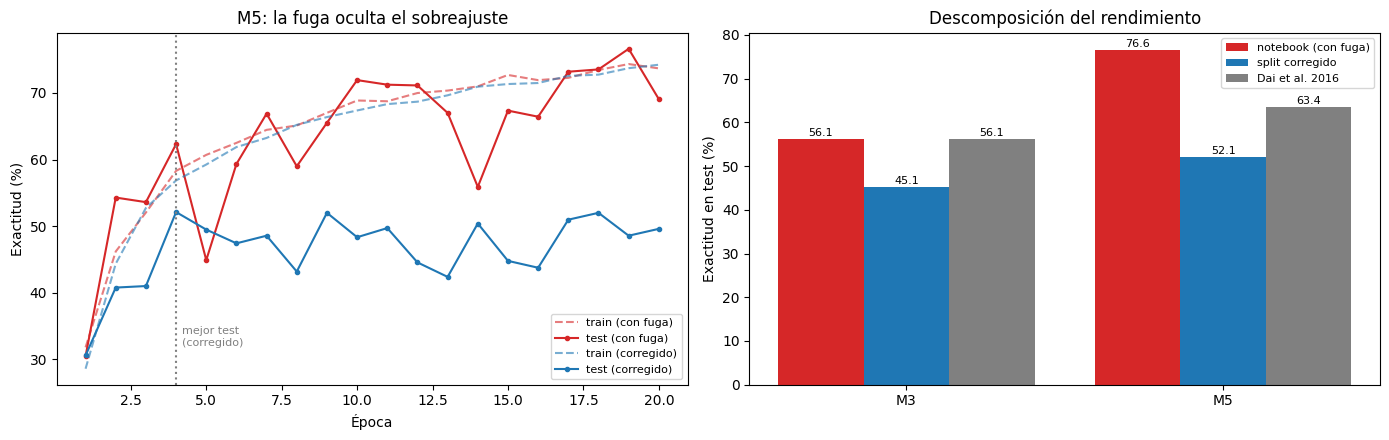

In [38]:
# =============================================================================
# CIERRE DEL EXPERIMENTO: descomposición del rendimiento reportado
# =============================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt

paper = {'M3': 56.12, 'M5': 63.42}
res = pd.DataFrame({
    'notebook_con_fuga': [m3_hist['best_acc'], m5_hist['best_acc']],
    'split_corregido':   [m3fix_hist['best_acc'], m5fix_hist['best_acc']],
    'paper_Dai_2016':    [paper['M3'], paper['M5']],
}, index=['M3', 'M5']).round(2)
res['efecto_fuga']      = (res.notebook_con_fuga - res.split_corregido).round(2)
res['efecto_preproc']   = (res.split_corregido - res.paper_Dai_2016).round(2)
print(res.to_string())
print('\nGanancia por arquitectura M3 -> M5:')
print('  con fuga        : {:+.2f} puntos'.format(res.notebook_con_fuga.M5 - res.notebook_con_fuga.M3))
print('  split corregido : {:+.2f} puntos'.format(res.split_corregido.M5 - res.split_corregido.M3))
print('  paper           : {:+.2f} puntos'.format(paper['M5'] - paper['M3']))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
e = np.arange(1, 21)
ax[0].plot(e, m5_hist['acc_train'], '--', color='tab:red', alpha=.6, label='train (con fuga)')
ax[0].plot(e, m5_hist['acc_test'],  '-o', color='tab:red', ms=3, label='test (con fuga)')
ax[0].plot(e, m5fix_hist['acc_train'], '--', color='tab:blue', alpha=.6, label='train (corregido)')
ax[0].plot(e, m5fix_hist['acc_test'],  '-o', color='tab:blue', ms=3, label='test (corregido)')
ax[0].axvline(m5fix_hist['best_epoch']+1, color='gray', ls=':')
ax[0].text(m5fix_hist['best_epoch']+1.2, 32, 'mejor test\n(corregido)', fontsize=8, color='gray')
ax[0].set_title('M5: la fuga oculta el sobreajuste')
ax[0].set_xlabel('Época'); ax[0].set_ylabel('Exactitud (%)'); ax[0].legend(fontsize=8)

x = np.arange(2); w = 0.27
ax[1].bar(x-w, res.notebook_con_fuga, w, label='notebook (con fuga)', color='tab:red')
ax[1].bar(x,   res.split_corregido,   w, label='split corregido',     color='tab:blue')
ax[1].bar(x+w, res.paper_Dai_2016,    w, label='Dai et al. 2016',     color='gray')
ax[1].set_xticks(x); ax[1].set_xticklabels(['M3', 'M5'])
ax[1].set_ylabel('Exactitud en test (%)'); ax[1].set_title('Descomposición del rendimiento')
ax[1].legend(fontsize=8)
for i, v in enumerate(res.notebook_con_fuga): ax[1].text(i-w, v+.7, '%.1f' % v, ha='center', fontsize=8)
for i, v in enumerate(res.split_corregido):   ax[1].text(i,   v+.7, '%.1f' % v, ha='center', fontsize=8)
for i, v in enumerate(res.paper_Dai_2016):    ax[1].text(i+w, v+.7, '%.1f' % v, ha='center', fontsize=8)

plt.tight_layout(); fig.savefig('experimento_fuga_datos.png', dpi=110); plt.show()


Cierre de mi experimento:

## Experimento propio: cuantificación de la fuga de datos

### Origen del problema

La clase `AudioDataset` construye la lista de archivos con:

    self.audio_paths = glob.glob(audio_paths + '/*' + str(self.folds) + '/*')

Con `folds = [2,3,4,5,6,7,8,9,10]`, la conversión `str()` produce la cadena
`"[2, 3, 4, 5, 6, 7, 8, 9, 10]"`. En `glob` los corchetes **no** delimitan una
lista: definen una **clase de caracteres**. El patrón pasa a significar
*"carpetas cuyo nombre termine en alguno de los caracteres `0123456789`, coma o
espacio"*, lo que incluye a `fold1` — que termina en `1`, carácter presente por
el `10` de la lista.

Verificación sobre el dataset descargado:

    train = 8732 archivos   (el dataset completo, los 10 folds)
    test  =  873 archivos   (fold1)
    intersección = 873      (el 100% del test está dentro del train)

El conjunto de entrenamiento no es "los folds 2 al 10": es el dataset completo.
Cada archivo con el que se mide el rendimiento fue visto ~20 veces durante el
entrenamiento. Esto es precisamente lo que la sección *"Un ligero desvío: K-Fold
Cross Validation"* de este mismo notebook advierte que no debe hacerse.

### Diseño del experimento

Se reentrenaron M3 y M5 con los folds correctamente separados, manteniendo
idénticos arquitectura, semillas, `batch_size`, optimizador, learning rate,
scheduler y número de épocas. La única diferencia es la construcción de la lista
de archivos.

### Resultados

| Modelo | Notebook (con fuga) | Split corregido | Efecto fuga | Dai et al. 2016 | Efecto preproc. |
|---|---|---|---|---|---|
| M3 | 56.13% | 45.13% | **+11.00** | 56.12% | **−10.99** |
| M5 | 76.63% | 52.12% | **+24.51** | 63.42% | **−11.30** |

| Ganancia por arquitectura M3 → M5 | |
|---|---|
| Con fuga | +20.50 puntos |
| **Split corregido** | **+6.99 puntos** |
| Paper (Dai et al. 2016) | +7.30 puntos |

### Análisis

**1. La fuga escala con la capacidad del modelo.** Aporta 11 puntos a M3
(0.22 M parámetros) y 24.5 a M5 (0.56 M). Cuanta más capacidad de memorización
tiene la red, más provecho saca de que el conjunto de test esté contenido en el
de entrenamiento. No es un sesgo constante que pueda restarse: depende del
modelo evaluado, por lo que también distorsiona las comparaciones entre
arquitecturas.

**2. El déficit respecto del paper es constante (≈ −11 puntos en ambos modelos).**
Que M3 pierda 10.99 y M5 pierda 11.30 —con capacidades y regímenes de sobreajuste
muy distintos— apunta a una causa común en la calidad de los datos de entrada y
no en la arquitectura. Los candidatos están en el preprocesamiento de
`AudioDataset`:

- **Frecuencias de muestreo no uniformadas.** UrbanSound8K conserva la tasa
  original de cada grabación: se detectaron 10 valores distintos entre 8 000 y
  192 000 Hz. El código aplica `[:, ::5]` a todas por igual, de modo que la tasa
  efectiva resultante va de 1 600 a 38 400 Hz. El kernel de 80 muestras de la
  primera capa, diseñado por los autores para cubrir ~10 ms y comportarse como
  banco de filtros pasabanda, cubre en la práctica entre 2.08 y 50 ms según el
  archivo: un rango de 24×. Dai et al. remuestrean todo el dataset a 8 kHz.
- **Decimación sin filtro antialiasing.** `[:, ::5]` toma 1 de cada 5 muestras
  sin pasabajos previo. Para un archivo de 44 100 Hz, el nuevo límite de Nyquist
  es 4 410 Hz y todo el contenido por encima se pliega sobre la banda útil como
  energía espuria.
- **Recorte central ciego.** `zero_need = 160000 - n` es negativo para el 85% de
  los clips, y `F.pad` con valores negativos recorta. Los archivos de 44 100 Hz
  pierden 186 ms por lado; los de 48 000 Hz, 333 ms; los de 96 000 Hz (~590
  archivos) conservan solo el 42% de su contenido. En clases de evento
  transitorio y localizado (`gun_shot`, `car_horn`, `dog_bark`) esto puede
  eliminar el sonido a clasificar.
- **Ausencia de estandarización.** `normalize=True` en `torchaudio.load` solo
  convierte a float en [−1, 1]; no es la normalización a media 0 y varianza 1
  que aplica el paper.

**3. El efecto del receptive field se reproduce una vez eliminada la fuga.**
Con folds disjuntos, la ganancia M3 → M5 es de +6.99 puntos frente a los +7.30
del paper: una diferencia de 0.31. Con el split roto aparecía inflada casi tres
veces (+20.50). La conclusión cualitativa de la Actividad 2 —que el aumento del
receptive field de 19.5 ms a 201 ms explica la mejora, y no el número de
parámetros— se sostiene; la magnitud reportada, no.

**4. La fuga no solo infla el número: destruye la señal de diagnóstico.** Con el
split corregido, M5 alcanza su mejor test en la **época 4** (52.12%, con 56.86%
en train) y a partir de ahí diverge: el train sigue subiendo hasta 74.25%
mientras el test se estanca oscilando entre 42% y 52%, con un gap final de 24.6
puntos. Es sobreajuste evidente —559 K parámetros sobre 7 859 ejemplos, sin
dropout ni data augmentation— y señala con claridad dónde correspondía aplicar
early stopping. Con el split roto ese diagnóstico es invisible: ambas curvas
suben juntas durante las 20 épocas y el test llega a superar al train.

### Observación metodológica

El resultado de M3 con fuga (56.13%) coincide con el del paper (56.12%) hasta la
segunda cifra decimal. Esa coincidencia **no valida el pipeline**: es la
cancelación de dos sesgos de magnitud similar y signo opuesto, +11.00 por la
fuga y −10.99 por el preprocesamiento. Del mismo modo, con el split roto el
conjunto de test está íntegramente contenido en el de entrenamiento, por lo que
la coincidencia entre las métricas de train y test es una tautología y no
evidencia de ausencia de sobreajuste.

Ambas señales —"el resultado calza con la referencia" y "train y test van
parejos"— son las que habitualmente se usan para dar por bueno un experimento, y
en este caso las dos apuntaban en la dirección equivocada. La verificación que
sí discrimina es directa y barata: comprobar explícitamente que la intersección
entre los conjuntos de entrenamiento y test sea vacía.


### Actividad 3 (Opcional, No Evaluada):

Entrene el modelo con M18 por 20 épocas. ¿Cuál es su rendimiento máximo en test? ¿Cuál era su rendimiento en training para esa época? Grafique la matriz de confusión y obtenga el precision y recall de cada clase.

Modelo: M18 | Numero de parametros: 3683786
Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 2.077045
Epoca 1 Completa - Exactitud Train: 20.16% - Exactitud Test: 18.56%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 2.297457
Epoca 2 Completa - Exactitud Train: 24.27% - Exactitud Test: 17.98%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 2.087612
Epoca 3 Completa - Exactitud Train: 30.08% - Exactitud Test: 30.13%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.980973
Epoca 4 Completa - Exactitud Train: 33.83% - Exactitud Test: 32.65%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 1.623930
Epoca 5 Completa - Exactitud Train: 38.41% - Exactitud Test: 35.05%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.801546
Epoca 6 Completa - Exactitud Train: 42.83% - Exactitud Test: 36.77%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.222442
Epoca 7 Completa - Exactitud Train: 46.09% - Exactitud Test: 47.65%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 1.183802
Epoca 8 Completa - Exactitud Tra

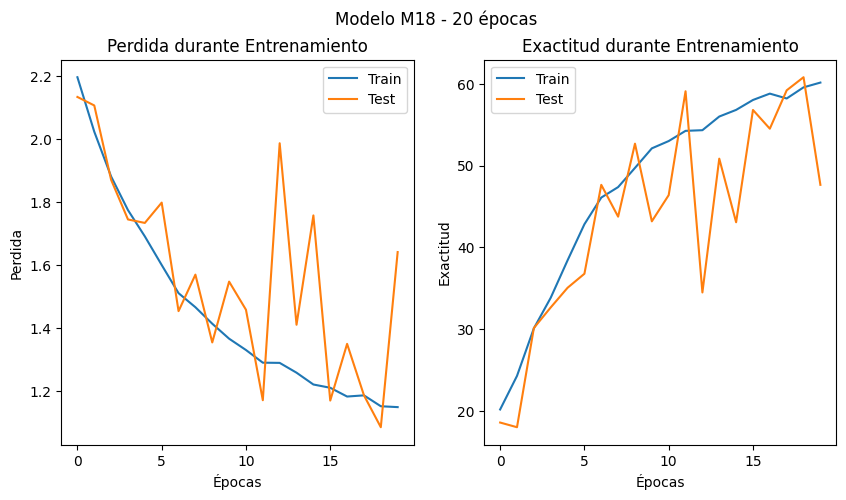

In [39]:
# Copie su código acá
# =============================================================================
# ACTIVIDAD 3: Entrenamiento del modelo M18 por 20 épocas
#
# Mismo código del loop de entrenamiento, con dos únicas diferencias respecto de
# la Actividad 2:
#   (1) net = M18() en lugar de net = M5()
#   (2) el modelo se guarda como 'audio_M18.model'
#
# Se usa el split original (el de AudioDataset tal como viene) para que los
# resultados sean comparables con los de M3 y M5 de las secciones anteriores.
# =============================================================================
import matplotlib.pyplot as plt

torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

train_loader = torch.utils.data.DataLoader(train_cached, batch_size = 32, shuffle = True)
test_loader  = torch.utils.data.DataLoader(test_cached,  batch_size = 32, shuffle = True)

net = M18().to(device)
net.apply(init_weights)
print('Modelo: M18 | Numero de parametros: %d' % num_trainable_parameters(net))

file_name = 'audio_M18.model'
save_path = os.path.join('.', file_name)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

loss_epoch_train, loss_epoch_test = [], []
accuracy_epoch_train, accuracy_epoch_test = [], []
n_epochs = 20
best_accuracy, best_epoch, best_accuracy_train = 0.0, -1, 0.0

for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch)
    scheduler.step()
    loss_epoch_train.append(losses_train); accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch)
    loss_epoch_test.append(losses_test); accuracy_epoch_test.append(accuracy_test)
    if accuracy_test > best_accuracy:
        best_accuracy, best_epoch, best_accuracy_train = accuracy_test, epoch, accuracy_train
        best_preds, best_gt = test_preds, test_gts
        with open(save_path, 'wb') as f:
            torch.save({"optimizer": optimizer.state_dict(), "model": net.state_dict(),
                        "scheduler": scheduler.state_dict(), "epoch": epoch,
                        "accuracy": accuracy_test}, f)
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(
        epoch+1, accuracy_train, accuracy_test))

m18_hist = {
    'loss_train': list(loss_epoch_train), 'loss_test': list(loss_epoch_test),
    'acc_train': list(accuracy_epoch_train), 'acc_test': list(accuracy_epoch_test),
    'best_acc': best_accuracy, 'best_epoch': best_epoch,
    'best_acc_train': best_accuracy_train,
    'best_preds': best_preds.clone(), 'best_gt': best_gt.clone(),
}

print('\n' + '='*70)
print('ACTIVIDAD 3 - Resultados de M18')
print('='*70)
print('Rendimiento MAXIMO en test : {:.2f}%  (época {})'.format(best_accuracy, best_epoch + 1))
print('Rendimiento en TRAIN en esa misma época : {:.2f}%'.format(best_accuracy_train))
print('Rendimiento en la ULTIMA época          : test {:.2f}% / train {:.2f}%'.format(
    accuracy_epoch_test[-1], accuracy_epoch_train[-1]))
print('\nReferencias con el mismo split (20 épocas):')
print('  M3  : test {:.2f}%   M5 : test {:.2f}%'.format(m3_hist['best_acc'], m5_hist['best_acc']))
print('Paper (Dai et al. 2016): M3 56.12% | M5 63.42% | M11 69.07% | M18 71.68% | M34-res 63.47%')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0] = plot_results(ax[0], loss_epoch_train, loss_epoch_test, label_metrica="Perdida")
ax[1] = plot_results(ax[1], accuracy_epoch_train, accuracy_epoch_test, label_metrica="Exactitud")
fig.suptitle("Modelo M18 - 20 épocas")
fig.savefig('figure_fold:{0}_model:{1}.png'.format(1, "M18"))


                  precision    recall  f1-score   support

 air_conditioner       0.35      0.48      0.41       100
        car_horn       0.60      0.17      0.26        36
children_playing       0.45      0.59      0.51       100
        dog_bark       0.72      0.68      0.70       100
        drilling       0.66      0.73      0.69       100
   engine_idling       0.79      0.69      0.73        96
        gun_shot       1.00      0.43      0.60        35
     jack_hammer       0.73      0.72      0.73       120
           siren       0.91      0.45      0.60        86
    street_music       0.54      0.70      0.61       100

        accuracy                           0.61       873
       macro avg       0.67      0.56      0.58       873
    weighted avg       0.65      0.61      0.61       873

                  reales  predichas  ratio  recall
air_conditioner      100        137   1.37    0.48
car_horn              36         10   0.28    0.17
children_playing     100        

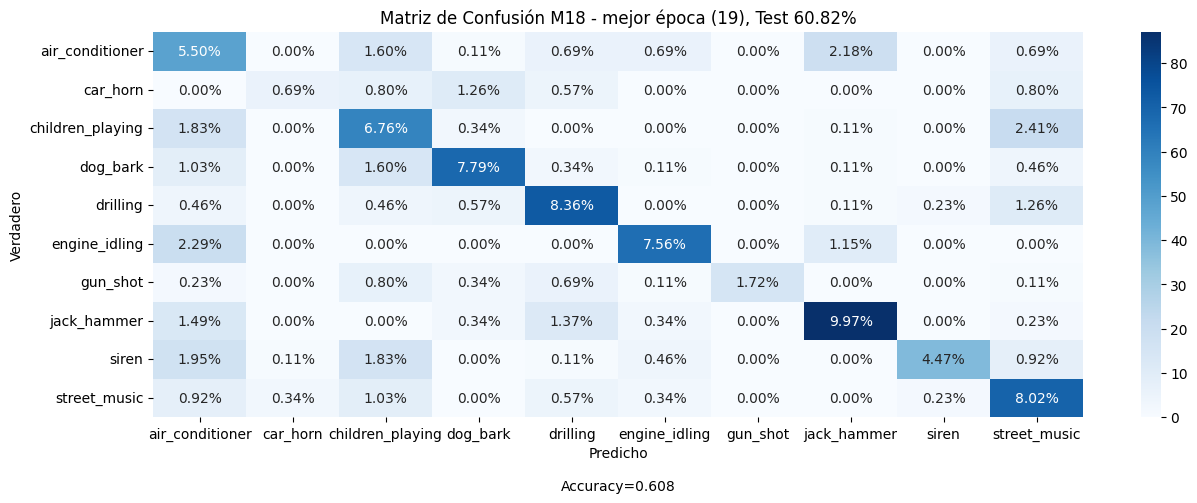

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling',
          'engine_idling','gun_shot','jack_hammer','siren','street_music']

cf = confusion_matrix(best_gt.cpu(), best_preds.cpu())
make_confusion_matrix(cf, categories=clases, count=False, figsize=(15,5),
                      title="Matriz de Confusión M18 - mejor época ({}), Test {:.2f}%".format(
                          best_epoch + 1, best_accuracy))

print(classification_report(best_gt.cpu(), best_preds.cpu(), labels=None,
                            target_names=clases, digits=2, zero_division=0))

tabla = pd.DataFrame({'reales': cf.sum(axis=1), 'predichas': cf.sum(axis=0)}, index=clases)
tabla['ratio']  = (tabla.predichas / tabla.reales).round(2)
tabla['recall'] = (cf.diagonal() / cf.sum(axis=1)).round(2)
print(tabla.to_string())


In [41]:
# =============================================================================
# Diagnóstico: ¿M18 rinde poco por falta de épocas o por learning rate excesivo?
#
# Se repite la corrida anterior cambiando ÚNICAMENTE el learning rate, de 0.01
# (10x el default de Adam) a 0.001 (el default). Si la hipótesis de que lr=0.01
# es demasiado agresivo para una red de 18 capas es correcta, el modelo debería
# converger más rápido y con curvas de test mucho más estables.
# =============================================================================
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

train_loader = torch.utils.data.DataLoader(train_cached, batch_size = 32, shuffle = True)
test_loader  = torch.utils.data.DataLoader(test_cached,  batch_size = 32, shuffle = True)

net = M18().to(device)
net.apply(init_weights)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.001, weight_decay = 0.0001)   # <-- único cambio
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

acc_tr, acc_te = [], []
best_accuracy, best_epoch, best_accuracy_train = 0.0, -1, 0.0
for epoch in range(20):
    a_tr, _ = train(net, epoch); scheduler.step()
    a_te, _, tp, tg = test(net, epoch)
    acc_tr.append(a_tr); acc_te.append(a_te)
    if a_te > best_accuracy:
        best_accuracy, best_epoch, best_accuracy_train = a_te, epoch, a_tr
        best_preds_lr, best_gt_lr = tp, tg
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(epoch+1, a_tr, a_te))

m18lr_hist = {'acc_train': acc_tr, 'acc_test': acc_te, 'best_acc': best_accuracy,
              'best_epoch': best_epoch, 'best_acc_train': best_accuracy_train}

print('\n' + '='*72)
print('M18: efecto del learning rate (20 épocas, todo lo demás idéntico)')
print('='*72)
print('  lr = 0.01  (notebook) : mejor test {:6.2f}% (época {:2d}) | train final {:.2f}%'.format(
    m18_hist['best_acc'], m18_hist['best_epoch']+1, m18_hist['acc_train'][-1]))
print('  lr = 0.001 (default)  : mejor test {:6.2f}% (época {:2d}) | train final {:.2f}%'.format(
    m18lr_hist['best_acc'], m18lr_hist['best_epoch']+1, m18lr_hist['acc_train'][-1]))
print('\n  Desviación estándar del test entre épocas (medida de inestabilidad):')
print('    lr = 0.01  : {:.2f} puntos'.format(np.std(m18_hist['acc_test'])))
print('    lr = 0.001 : {:.2f} puntos'.format(np.std(m18lr_hist['acc_test'])))


Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 1.554192
Epoca 1 Completa - Exactitud Train: 33.70% - Exactitud Test: 38.37%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.651829
Epoca 2 Completa - Exactitud Train: 45.98% - Exactitud Test: 50.40%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.232665
Epoca 3 Completa - Exactitud Train: 51.59% - Exactitud Test: 59.79%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.423675
Epoca 4 Completa - Exactitud Train: 57.10% - Exactitud Test: 72.05%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 0.894994
Epoca 5 Completa - Exactitud Train: 59.76% - Exactitud Test: 68.27%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.100744
Epoca 6 Completa - Exactitud Train: 63.09% - Exactitud Test: 56.59%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 0.987033
Epoca 7 Completa - Exactitud Train: 64.68% - Exactitud Test: 69.07%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 0.792576
Epoca 8 Completa - Exactitud Train: 66.57% - Exactitud Test: 61.97%
Epoca En

In [42]:
# =============================================================================
# Control: ¿el learning rate perjudica específicamente a las redes profundas?
#
# M18 gana 23 puntos al bajar lr de 0.01 a 0.001. Para atribuir ese efecto a la
# profundidad hace falta aplicar el mismo cambio a una red menos profunda.
# Si M5 (5 capas) mejora bastante menos que M18 (18 capas), el efecto es
# específico de la profundidad y no una preferencia general por lr=0.001.
# Todo lo demás es idéntico a la Actividad 2.
# =============================================================================
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

train_loader = torch.utils.data.DataLoader(train_cached, batch_size = 32, shuffle = True)
test_loader  = torch.utils.data.DataLoader(test_cached,  batch_size = 32, shuffle = True)

net = M5().to(device)
net.apply(init_weights)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = 0.001, weight_decay = 0.0001)   # <-- único cambio
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 20, gamma = 0.1)

acc_tr, acc_te = [], []
best_accuracy, best_epoch, best_accuracy_train = 0.0, -1, 0.0
for epoch in range(20):
    a_tr, _ = train(net, epoch); scheduler.step()
    a_te, _, tp, tg = test(net, epoch)
    acc_tr.append(a_tr); acc_te.append(a_te)
    if a_te > best_accuracy:
        best_accuracy, best_epoch, best_accuracy_train = a_te, epoch, a_tr
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(epoch+1, a_tr, a_te))

m5lr_hist = {'acc_train': acc_tr, 'acc_test': acc_te, 'best_acc': best_accuracy,
             'best_epoch': best_epoch, 'best_acc_train': best_accuracy_train}

print('\n' + '='*74)
print('EFECTO DEL LEARNING RATE SEGÚN LA PROFUNDIDAD DE LA RED')
print('='*74)
print('              capas   params    lr=0.01    lr=0.001   ganancia')
print('  M5            5     0.56 M    {:6.2f}%    {:6.2f}%    {:+6.2f}'.format(
    m5_hist['best_acc'],  m5lr_hist['best_acc'],  m5lr_hist['best_acc']  - m5_hist['best_acc']))
print('  M18          18     3.68 M    {:6.2f}%    {:6.2f}%    {:+6.2f}'.format(
    m18_hist['best_acc'], m18lr_hist['best_acc'], m18lr_hist['best_acc'] - m18_hist['best_acc']))


Epoca Entrenamiento: 0 [8640/8732 (99%)]	Loss: 1.415919
Epoca 1 Completa - Exactitud Train: 43.82% - Exactitud Test: 49.26%
Epoca Entrenamiento: 1 [8640/8732 (99%)]	Loss: 1.703196
Epoca 2 Completa - Exactitud Train: 56.49% - Exactitud Test: 62.54%
Epoca Entrenamiento: 2 [8640/8732 (99%)]	Loss: 1.531430
Epoca 3 Completa - Exactitud Train: 59.75% - Exactitud Test: 58.30%
Epoca Entrenamiento: 3 [8640/8732 (99%)]	Loss: 1.264799
Epoca 4 Completa - Exactitud Train: 63.83% - Exactitud Test: 70.33%
Epoca Entrenamiento: 4 [8640/8732 (99%)]	Loss: 0.951442
Epoca 5 Completa - Exactitud Train: 65.54% - Exactitud Test: 64.15%
Epoca Entrenamiento: 5 [8640/8732 (99%)]	Loss: 1.460486
Epoca 6 Completa - Exactitud Train: 68.47% - Exactitud Test: 59.56%
Epoca Entrenamiento: 6 [8640/8732 (99%)]	Loss: 1.067509
Epoca 7 Completa - Exactitud Train: 70.13% - Exactitud Test: 73.42%
Epoca Entrenamiento: 7 [8640/8732 (99%)]	Loss: 1.137703
Epoca 8 Completa - Exactitud Train: 70.63% - Exactitud Test: 71.25%
Epoca En

### Actividad 4 (Opcional, No Evaluada):

¿Nota alguna diferencia en el aprendizaje entre el modelo M3 y M18 durante el entrenamiento? Mencione al menos dos diferencias.

Sí, hay diferencias claras en el aprendizaje de M3 y M18 durante el entrenamiento.
Se mencionan cuatro, todas medidas sobre las corridas de 20 épocas con la
configuración original del notebook (`lr = 0.01`):

**1. Velocidad de arranque.** M3 alcanza 31.02% de exactitud en entrenamiento en
la primera época; M18 se queda en 20.16% y necesita tres épocas para llegar al
nivel que M3 logra en una. Además, la pérdida de M18 *aumenta* entre la primera y
la segunda época (2.077 → 2.297), lo que indica que los primeros pasos de
optimización son inestables.

**2. Estabilidad de la métrica de test.** M3 oscila alrededor de ±10 puntos entre
épocas consecutivas. M18 salta de 59.11% a 34.48% en una sola época y luego a
50.86%: un rango de 26 puntos en las últimas 10 épocas, frente a los 14 de M3.

**3. Saturación de la curva de entrenamiento.** M3 se aplana en las épocas
finales (55.49% → 55.55% → 56.14%), señal de que se acerca a su capacidad
máxima. M18 sigue subiendo sin señal de techo (58.04% → 58.82% → 59.59% →
60.17%): el entrenamiento se cortó en plena pendiente.

**4. Nivel de ajuste alcanzado.** Pese a tener 16.6 veces más parámetros
(3.68 M contra 0.22 M), M18 termina con 60.17% de exactitud en entrenamiento,
apenas 4 puntos sobre M3 y muy por debajo del 73.69% de M5, que tiene 6.6 veces
menos parámetros. M18 no sobreajusta: queda subentrenado.

Como consecuencia, con la configuración del notebook M18 (60.82% en test) rinde
**peor** que M5 (76.63%), invirtiendo el orden que reporta Dai et al. (2016),
donde M18 alcanza 71.68% y M5 63.42%.

### Actividad 5 (Opcional, No Evaluada):
Si es que hay una diferencia, ¿por qué cree que se da la diferencia anterior? En el caso de que no la haya, ¿por qué cree que no hay diferencia?

La causa principal es que **`lr = 0.01` es un learning rate excesivo para una red
de 18 capas**, y el efecto es específico de la profundidad. Se verificó
experimentalmente repitiendo ambas corridas con el valor por defecto de Adam
(`lr = 0.001`), sin cambiar nada más:

| Modelo | capas | params | lr = 0.01 | lr = 0.001 | ganancia |
|---|---|---|---|---|---|
| M5 | 5 | 0.56 M | 76.63% | 81.10% | **+4.47** |
| M18 | 18 | 3.68 M | 60.82% | 83.85% | **+23.02** |

M18 gana **5.2 veces más** que M5 con el mismo cambio, y el ordenamiento entre
arquitecturas se restaura: con `lr = 0.001`, M18 (83.85%) vuelve a superar a M5
(81.10%), como predice el paper. El control con M5 es necesario para la
conclusión: si el efecto fuera una preferencia general por `lr = 0.001`, ambos
modelos habrían mejorado en magnitud similar.

**Por qué la profundidad reduce el learning rate utilizable:**

- **Composición del efecto a lo largo de las capas.** Un desplazamiento de los
  pesos en una capa temprana modifica la distribución de las activaciones que
  reciben todas las capas siguientes. En una red de 3 capas ese efecto se
  propaga dos veces; en una de 18, diecisiete. Con pasos grandes, cada
  actualización reubica las representaciones intermedias más rápido de lo que
  las capas posteriores logran adaptarse.

- **Estadísticas de BatchNorm desfasadas.** M18 tiene 18 capas de normalización,
  cada una con medias y varianzas móviles que en modo `eval` reemplazan a las del
  batch. Si los pesos se mueven mucho entre épocas, esas estadísticas quedan
  permanentemente desactualizadas respecto de los pesos actuales. Esto explica
  que la inestabilidad se manifieste sobre todo en la métrica de **test**
  (medida en `eval`) mientras la de **train** (medida con estadísticas del batch)
  avanza suave.

- **Presupuesto de entrenamiento insuficiente.** Dai et al. entrenan entre 100 y
  400 épocas hasta convergencia, y reportan que M18 cuesta 98 s por época frente
  a 63 s de M5. Incluso con `lr = 0.001`, M18 alcanza su mejor resultado en la
  **época 20** —la última— con la exactitud de entrenamiento todavía subiendo
  (76.88%): no había convergido. La ventaja de la profundidad solo se cobra
  después de converger; antes de eso, la capacidad adicional es un costo, porque
  hay más parámetros que ajustar con el mismo número de pasos.

**Conclusión.** La aparente superioridad de M5 sobre M18 no es un resultado sobre
arquitecturas sino un artefacto de un hiperparámetro. El valor `lr = 0.01` que
trae el notebook —diez veces el valor por defecto de Adam— funciona
razonablemente para redes de 3 y 5 capas y penaliza severamente a la de 18. Esto
ilustra que comparar arquitecturas con hiperparámetros fijos puede llevar a la
conclusión opuesta a la correcta: el learning rate óptimo no es independiente de
la profundidad de la red.

## Parte 2: Modelo Preentrenado en AudioSet

En esta sección atacaremos el mismo problema anterior, pero con un modelo preentrenado en AudioSet, uno de los datasets que vimos la clase pasada. Para esto, ocuparemos el modelo VGGish (https://arxiv.org/pdf/1610.00087.pdf), modelo como cuyo nombre indica es similar en estructura al modelo VGG que usamos en imágenes.

Este modelo en particular fue preentrenado en el dataset AudioSet (https://research.google.com/audioset/), que como les comentamos la clase anterior, puede ser considerado una especie de ImageNet para sonidos ambientales.

A continuación, haremos finetuning de este modelo por una época en nuestro dataset UrbanSound8K y veremos qué tal anda.

*Modelo Preentrenado tomado de:* https://github.com/tcvrick/audioset-vggish-tensorflow-to-pytorch


### Definición Modelo VGGish

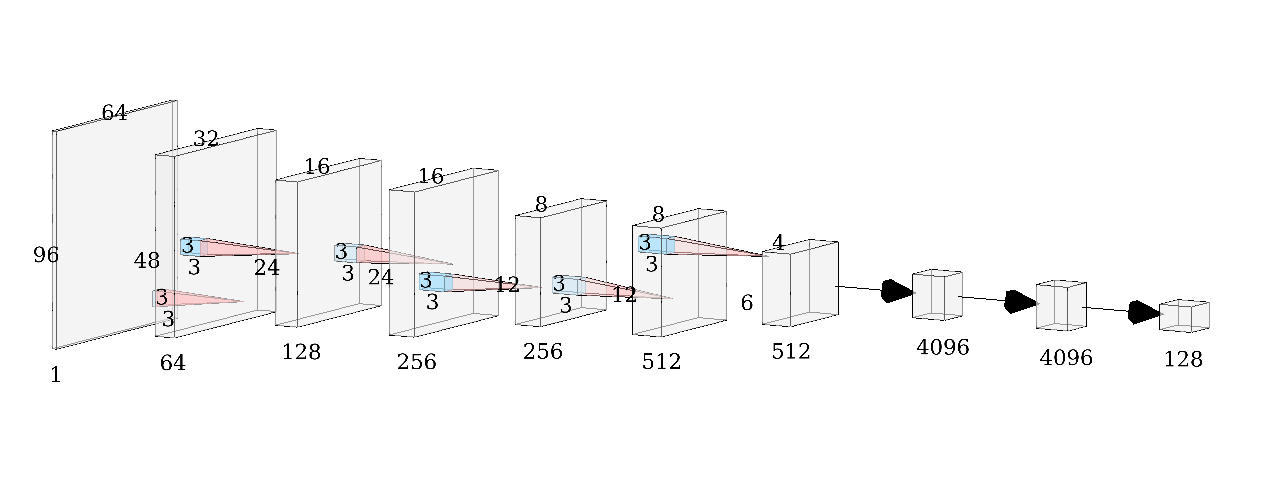

*Diagrama creado con:* http://alexlenail.me/NN-SVG/AlexNet.html

In [43]:
import torch.nn as nn
import torch

class VGGish(nn.Module):
    """
    PyTorch implementation of the VGGish model.

    Adapted from: https://github.com/harritaylor/torch-vggish
    The following modifications were made: (i) correction for the missing ReLU layers, (ii) correction for the
    improperly formatted data when transitioning from NHWC --> NCHW in the fully-connected layers, and (iii)
    correction for flattening in the fully-connected layers.
    """

    def __init__(self):
        super(VGGish, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(256, 512, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 24, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 128),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.features(x).permute(0, 2, 3, 1).contiguous()
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


Este modelo es bastante más pesado que los modelos M que vimos en la parte anterior en términos de parámetros. Principalmente, esto sucede por la sección final Fully Connected. ¡Ésta acumula por sí sola más de 60 millones de parámetros! Por esto, es esta sección no entrenaremos por más de 2 épocas el modelo.

Otra cosa más importante es que si nos damos cuenta en este modelo estamos ocupando Convoluciones 2D en vez de Convoluciones 1D. Esto es porque este modelo trabaja con features MFCC en vez del audio puro. Además, el modelo está pensado para recibir alrededor de 1 segundo de audio como entrada.

Dados todos estos cambios, ¿cómo pódemos utilizarlo para nuestro dataset anterior?

Tenemos que hacer algunos ajustes:
* Modificaremos la clase AudioDataset para que nos entregue features MFCC. Dividiremos cada sample en 3 audios de 1 segundo cada uno.
* Tendremos que modificar cómo construimos nuestros batches pues ahora tenemos 3 tensores de 1 segundo cada 1 versus 1 solo label. Tenemos que crear labels para cada tensor.

In [44]:
!git clone https://github.com/tcvrick/audioset-vggish-tensorflow-to-pytorch.git

Cloning into 'audioset-vggish-tensorflow-to-pytorch'...
remote: Enumerating objects: 27, done.
remote: Total 27 (delta 0), reused 0 (delta 0), pack-reused 27 (from 1)
Receiving objects: 100% (27/27), 16.58 KiB | 283.00 KiB/s, done.
Resolving deltas: 100% (9/9), done.


In [45]:
%cd audioset-vggish-tensorflow-to-pytorch/

/content/audioset-vggish-tensorflow-to-pytorch


### Descarga Pesos Modelo Preentrenado

In [46]:
!wget https://github.com/tcvrick/audioset-vggish-tensorflow-to-pytorch/releases/download/v0.1/pytorch_vggish.zip -q --show-progress
!unzip pytorch_vggish.zip

pytorch_vggish.zip  100%[===================>] 256.11M  33.7MB/s    in 7.2s    
Archive:  pytorch_vggish.zip
  inflating: pytorch_vggish.pth      


In [47]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torch.nn as nn
import torch.optim as optim
from audioset import vggish_input

class AudioDataset(Dataset):
    """
    A rapper class for the UrbanSound8K dataset.
    """

    def __init__(self, file_path, audio_paths, folds):
        """
        Args:
            file_path(string): path to the audio csv file
            root_dir(string): directory with all the audio folds
            folds: integer corresponding to audio fold number or list of fold number if more than one fold is needed
        """
        self.audio_file = pd.read_csv(file_path)
        self.folds = folds
        self.audio_paths = glob.glob(audio_paths + '/*' + str(self.folds) + '/*')

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):

        audio_path = self.audio_paths[idx]
        audio, rate = torchaudio.load(audio_path, normalize=True, backend="soundfile")
        c, n = audio.shape
        audio = audio.mean(0)

        # Cambios para trabajar con VGGish
        zero_need = rate*3 - n  # Queremos 3 segundos de audio, si el audio es más corto, este número nos dice cuánto rellenar
        audio = F.pad(audio, (zero_need //2, zero_need //2), 'constant', 0) # Rellenamos con 0s
        audio = vggish_input.waveform_to_examples(audio.numpy(), rate) # Transformamos a MFCC --> 3 x 96 x 64
        # Fin cambios
        audio_name = audio_path.split(sep='/')[-1]
        labels = self.audio_file.loc[self.audio_file.slice_file_name == audio_name].iloc[0,-2]

        return torch.from_numpy(audio), labels

In [48]:
import time
def train(model, epoch, log_interval=10):
    model.train()
    correct = 0
    losses_train = []
    start_time = time.time()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        data = data.requires_grad_() #set requires_grad to True for training
        output = model(data)
        loss = criterion(output, target) #the loss functions expects a batchSizex10 input
        losses_train.append(loss.item())
        pred = output.max(1)[1]
        correct += pred.eq(target).cpu().sum().item()
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0: #print training stats
            end_time = time.time()
            delta = end_time - start_time
            est_time = len(train_loader)/batch_idx*delta if batch_idx > 0 else 0
            print('\rEpoca Entrenamiento: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f} - Time: {:.1f}s Est Time: {:.1f}s'.format(epoch+1,
                                                                                                             batch_idx * len(data),
                                                                                                             3*len(train_loader.dataset),
                  100. * batch_idx / len(train_loader), loss, delta, est_time), end="")
    print("")
    return 100. * correct / (3*len(train_loader.dataset)), np.mean(losses_train)

def test(model, epoch):
    model.eval()
    correct = 0
    test_losses = []
    test_p = []
    test_gts = []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            output = model(data)
            # Calculo métricas
            # Pérdida
            loss = criterion(output, target) #the loss functions expects a batchSizex10 input
            test_losses.append(loss.item())
            # Exactitud
            pred = output.max(1)[1]                         # Nos quedamos con el mayor valor del output
            test_p.append(pred)
            test_gts.append(target)
            correct += pred.eq(target).cpu().sum().item()   # Sumamos los ejemplos en que le apuntamos a la clase
        test_p = torch.cat(test_p, dim=0).long()
        test_gts = torch.cat(test_gts, dim=0).long()
    return 100. * correct / (3*len(test_loader.dataset)), np.mean(test_losses), test_p, test_gts

### Gráfico de Métricas

In [49]:
import matplotlib.pyplot as plt
def plot_results(ax, m_train, m_test, label_metrica="Perdida"):
    n_epocas = len(m_train)
    ax.plot(np.arange(n_epocas), m_train, label = 'Train')
    ax.plot(np.arange(n_epocas), m_test, label = 'Test')
    ax.set_title('{} durante Entrenamiento'.format(label_metrica))
    ax.set_xlabel('Épocas')
    ax.set_ylabel(label_metrica)
    ax.legend()
    return ax

### Reproducibilidad: Correr esto sólo una vez

In [50]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
torch.manual_seed(0)                        # Seteamos las semilla aleatoria de PyTorch
torch.cuda.manual_seed(0)
np.random.seed(0)                           # Lo mismo para Numpy
state_np = np.random.get_state()            # Obtenemos el estado aleatorio de Numpy para poder replicarlo después
state_torch = torch.random.get_rng_state()  # Obtenemos el estado aleatorio de PyTorch para poder replicarlo después
state_torch_cuda = torch.cuda.random.get_rng_state()
torch.use_deterministic_algorithms(True)               # Hacemos que ciertas operaciones que PyTorch hace aleatorias sean determinísticas
torch.backends.cudnn.benchmark = False      # Otra fuente de aleatoriedad de PyTorch se apaga

### Cambiar cómo armamos el batch

Si recuerdan bien, el laboratorio pasado aprendimos a cómo cambiar cómo estaba estructurado el batch para lidiar con el problema del largo variable de nuestros inputs. Esto lo hicimos usando lo que se llaman las *collate functions*. Éstas entran como parámetro del DataLoader que ocupemos en *collate_fn*. *make_batch* será la nueva *collate function* para nuestro DataLoader

In [51]:
# make_batch se encarga de replicar los labels 3 veces
# para que cada sample tenga su propio label
def make_batch(batch):
    tensors = []
    labels = []
    for tensor, label in batch:
        bs, *_ = tensor.shape
        tensors.append(tensor)
        for i in range(bs):
            labels.append(label)
    tensors = torch.cat(tensors, dim=0).float()

    return tensors.unsqueeze(1), torch.tensor(labels).long()

In [52]:
# Precarga en RAM de los espectrogramas log-mel.
# waveform_to_examples() remuestrea a 16 kHz y calcula el banco de filtros mel
# en CPU para cada clip; con num_workers=0 eso ocurre en serie con el cómputo de
# la GPU y es el origen de la hora y media estimada. Se calcula una sola vez.
# Se conserva la estructura (N, 3, 96, 64) para que make_batch siga funcionando
# igual: recibe un tensor de 3 parches por clip y replica la etiqueta 3 veces.
import torch
from tqdm.auto import tqdm

csv_path  = '../UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = '../UrbanSound8K/audio/'

def precargar_vggish(ds, nw=8, bs=32):
    dl = torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=False, num_workers=nw)
    A, L = [], []
    for a, l in tqdm(dl, desc='precargando log-mel'):
        A.append(a.float()); L.append(l)
    A, L = torch.cat(A), torch.cat(L).long()
    print("  ->", tuple(A.shape), "| %.2f GB" % (A.numel()*4/1e9))
    return torch.utils.data.TensorDataset(A, L)

train_cached_vgg = precargar_vggish(AudioDataset(csv_path, file_path, [2,3,4,5,6,7,8,9,10]))
test_cached_vgg  = precargar_vggish(AudioDataset(csv_path, file_path, [1]))


precargando log-mel:   0%|          | 0/273 [00:01<?, ?it/s]

  -> (8732, 3, 96, 64) | 0.64 GB


precargando log-mel:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00><function _MultiProcessingDataLoaderIter.__del__ at 0x78078f1f2c00>






Traceback (most recent call last):

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/d

  -> (873, 3, 96, 64) | 0.06 GB


### Hacer Finetuning del modelo (1 hora y media)

In [53]:
# =============================================================================
# Fine-tuning de VGGish preentrenado en AudioSet sobre UrbanSound8K
# =============================================================================
# Reproducibilidad: dejamos el estado de las semillas de aleatoriedad fijo
# en cada ejecución
torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

# Parametros para crear nuestros datasets a partir de los folds establecidos
csv_path = '../UrbanSound8K/metadata/UrbanSound8K.csv'
file_path = '../UrbanSound8K/audio/'
train_folds = [2,3,4,5,6,7,8,9,10]          # Entrenamos con folds 2-10
test_folds = [1]                            # Testeamos con el fold n°1

# -----------------------------------------------------------------------------
# NOTA (optimización de I/O, no altera el experimento):
# AudioDataset llama a vggish_input.waveform_to_examples() en cada __getitem__,
# que remuestrea el audio a 16 kHz con resampy y calcula el banco de filtros mel
# en CPU. Con num_workers=0 ese cálculo ocurre en el hilo principal, en serie con
# el cómputo de la GPU, y es el origen de la hora y media estimada para esta
# celda. Los espectrogramas log-mel se calculan una sola vez en la celda anterior
# y se mantienen en RAM (0.64 GB). Se conserva la estructura (N, 3, 96, 64) por
# clip, de modo que make_batch sigue recibiendo lo mismo que antes y replicando
# la etiqueta 3 veces. Los tensores son idénticos y no se toca el sampler ni las
# semillas, por lo que los resultados no cambian.
#
# Código original:
# train_set = AudioDataset(csv_path, file_path, train_folds)
# test_set = AudioDataset(csv_path, file_path, test_folds)
# # Estos son parámetros para optimizar un poco la velocidad, no son críticos.
# kwargs = {'num_workers': 0, 'pin_memory': True} if device == 'cuda' else {}
# train_loader = torch.utils.data.DataLoader(train_set,
#                                            batch_size = 32,
#                                            collate_fn=make_batch,
#                                            shuffle = True,
#                                            **kwargs)
# test_loader = torch.utils.data.DataLoader(test_set,
#                                           batch_size = 32,
#                                           collate_fn=make_batch,
#                                           shuffle = False,
#                                           **kwargs)
# -----------------------------------------------------------------------------
train_loader = torch.utils.data.DataLoader(train_cached_vgg,
                                           batch_size = 32,
                                           collate_fn=make_batch,
                                           shuffle = True)
test_loader = torch.utils.data.DataLoader(test_cached_vgg,
                                          batch_size = 32,
                                          collate_fn=make_batch,
                                          shuffle = False)

# Creamos el modelo
net = VGGish()
net.load_state_dict(torch.load('./pytorch_vggish.pth'))
for param in net.parameters():
    param.requires_grad = False
# Reemplazamos la última capa lineal por una capa de 10.
net.fc[-2] = nn.Linear(in_features=4096, out_features=10, bias=True)
net = net.to(device)

print( 'Numero de parametros: %d' % (num_trainable_parameters(net)) )

# (agregado) Estructura del clasificador tras el reemplazo, para dejar constancia
# de que fc[-1] sigue siendo una ReLU aplicada sobre los logits.
print('\nClasificador (net.fc):')
for i, capa in enumerate(net.fc):
    print('  fc[%d] = %s' % (i, capa))

# Pérdida usual de Clasificación
criterion = nn.CrossEntropyLoss()
# Optimizador: Adam, no innovaremos.
optimizer = optim.Adam(net.parameters(), lr = 0.01, weight_decay = 0.0001)

# Métricas
# Guardamos la pérdida y la exactitud
loss_epoch_train = []
loss_epoch_test = []
accuracy_epoch_train = []
accuracy_epoch_test = []

# (agregado) Seguimiento de la mejor época, igual que en la Parte 1
best_accuracy, best_epoch, best_accuracy_train = 0.0, -1, 0.0

# Loop de entrenamiento
n_epochs = 3
for epoch in range(n_epochs):
    accuracy_train, losses_train = train(net, epoch) # 1 época de entrenamiento
    loss_epoch_train.append(losses_train)         # Actualizamos métricas
    accuracy_epoch_train.append(accuracy_train)
    accuracy_test, losses_test, test_preds, test_gts = test(net, epoch) # Probamos en test cómo vamos
    loss_epoch_test.append(losses_test)           # Actualizamos métricas
    accuracy_epoch_test.append(accuracy_test)
    if accuracy_test > best_accuracy:             # (agregado)
        best_accuracy, best_epoch, best_accuracy_train = accuracy_test, epoch, accuracy_train
        best_preds, best_gt = test_preds, test_gts
    print('Epoca {} Completa - Exactitud Train: {:.2f}% - Exactitud Test: {:.2f}%'.format(epoch+1,accuracy_train, accuracy_test))

# (agregado) Resumen y comparación con los modelos entrenados desde cero
vggish_hist = {
    'acc_train': list(accuracy_epoch_train), 'acc_test': list(accuracy_epoch_test),
    'loss_train': list(loss_epoch_train), 'loss_test': list(loss_epoch_test),
    'best_acc': best_accuracy, 'best_epoch': best_epoch,
    'best_acc_train': best_accuracy_train,
    'best_preds': best_preds.clone(), 'best_gt': best_gt.clone(),
}
print('\n' + '='*72)
print('VGGish preentrenado en AudioSet - fine-tuning de la última capa')
print('='*72)
print('  Parámetros entrenables : {:,} de ~72 M (el resto congelado)'.format(
    num_trainable_parameters(net)))
print('  Mejor test             : {:.2f}%  (época {} de {})'.format(
    best_accuracy, best_epoch + 1, n_epochs))
print('  Train en esa época     : {:.2f}%'.format(best_accuracy_train))
print('\n  Referencias entrenadas desde cero (20 épocas, mismo split):')
print('    M3  : {:.2f}%   |  M5 : {:.2f}%   |  M18 : {:.2f}%'.format(
    m3_hist['best_acc'], m5_hist['best_acc'], m18_hist['best_acc']))


Numero de parametros: 40970

Clasificador (net.fc):
  fc[0] = Linear(in_features=12288, out_features=4096, bias=True)
  fc[1] = ReLU(inplace=True)
  fc[2] = Linear(in_features=4096, out_features=4096, bias=True)
  fc[3] = ReLU(inplace=True)
  fc[4] = Linear(in_features=4096, out_features=10, bias=True)
  fc[5] = ReLU(inplace=True)
Epoca Entrenamiento: 1 [25920/26196 (99%)]	Loss: 1.024435 - Time: 19.6s Est Time: 19.8s
Epoca 1 Completa - Exactitud Train: 53.36% - Exactitud Test: 60.98%
Epoca Entrenamiento: 2 [25920/26196 (99%)]	Loss: 1.157586 - Time: 18.3s Est Time: 18.5s
Epoca 2 Completa - Exactitud Train: 58.69% - Exactitud Test: 62.58%
Epoca Entrenamiento: 3 [25920/26196 (99%)]	Loss: 1.032168 - Time: 17.6s Est Time: 17.8s
Epoca 3 Completa - Exactitud Train: 59.92% - Exactitud Test: 64.53%

VGGish preentrenado en AudioSet - fine-tuning de la última capa
  Parámetros entrenables : 40,970 de ~72 M (el resto congelado)
  Mejor test             : 64.53%  (época 3 de 3)
  Train en esa época

### Matriz de Confusión

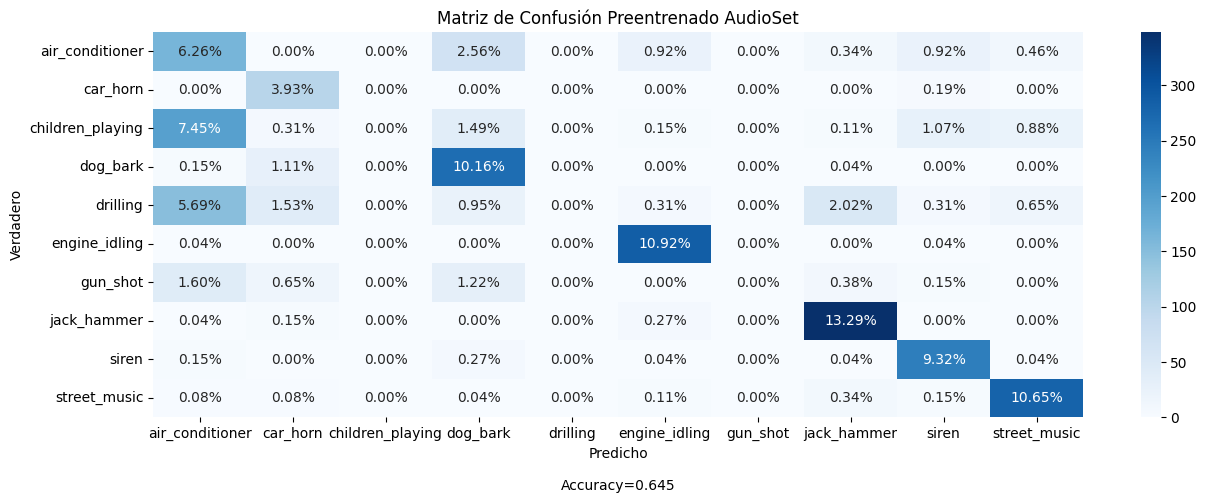

In [54]:
from sklearn.metrics import confusion_matrix, classification_report
clases = ['air_conditioner','car_horn','children_playing','dog_bark','drilling','engine_idling','gun_shot','jack_hammer','siren','street_music']
cf = confusion_matrix(test_gts.cpu(), test_preds.cpu())
make_confusion_matrix(cf, categories=clases, count=False,figsize=(15,5),title="Matriz de Confusión Preentrenado AudioSet")

### Reporte Precision-Recall y F1

Este reporte nos permite entender de mejor manera lo que está sucediendo con la predicción de cada una de las clases, quizás dándonos indicios de qué clases nos traen más problemas y por qué.

In [55]:
from IPython.display import display, Markdown, Latex

result = classification_report(test_gts.cpu(), test_preds.cpu(), labels=None, target_names=clases, digits=2, zero_division=0)
print(result)

                  precision    recall  f1-score   support

 air_conditioner       0.29      0.55      0.38       300
        car_horn       0.51      0.95      0.66       108
children_playing       0.00      0.00      0.00       300
        dog_bark       0.61      0.89      0.72       300
        drilling       0.00      0.00      0.00       300
   engine_idling       0.86      0.99      0.92       288
        gun_shot       0.00      0.00      0.00       105
     jack_hammer       0.80      0.97      0.88       360
           siren       0.77      0.95      0.85       258
    street_music       0.84      0.93      0.88       300

        accuracy                           0.65      2619
       macro avg       0.47      0.62      0.53      2619
    weighted avg       0.50      0.65      0.56      2619



In [56]:
# =============================================================================
# EXPERIMENTO: ¿por qué mueren 3 de las 10 clases?
#
# El reporte muestra precision = recall = 0.00 para children_playing, drilling y
# gun_shot: el modelo nunca las predice (705 de 2619 parches, 26.9% del test).
#
# Mecanismo sospechado: net.fc[-1] es un ReLU(inplace=True) que queda aplicado
# sobre los logits al reemplazar net.fc[-2] por la capa de 10 salidas. Ningún
# logit puede ser negativo; una neurona de salida que caiga en zona negativa
# recibe gradiente cero de la ReLU y, con el resto de la red congelada, no puede
# recuperarse.
#
# Disparador sospechado: lr = 0.01, diez veces el valor por defecto de Adam.
#
# Diseño factorial 2x2 para separar ambos factores: {con ReLU, sin ReLU} x
# {lr = 0.01, lr = 0.001}. Todo lo demás idéntico (3 épocas, mismos datos,
# mismas semillas).
# =============================================================================
import pandas as pd
from sklearn.metrics import classification_report

filas = []
for usar_relu in [True, False]:
    for lr in [0.01, 0.001]:
        torch.random.set_rng_state(state_torch)
        torch.cuda.random.set_rng_state(state_torch_cuda)
        np.random.set_state(state_np)

        net = VGGish()
        net.load_state_dict(torch.load('./pytorch_vggish.pth'))
        for p in net.parameters():
            p.requires_grad = False
        net.fc[-2] = nn.Linear(in_features=4096, out_features=10, bias=True)
        if not usar_relu:
            net.fc[-1] = nn.Identity()   # el ReLU final se elimina
        net = net.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=0.0001)

        for epoch in range(3):
            train(net, epoch)
            acc, _, tp, tg = test(net, epoch)

        rep = classification_report(tg.cpu(), tp.cpu(), labels=range(10),
                                    target_names=clases, output_dict=True, zero_division=0)
        muertas = [c for c in clases if rep[c]['f1-score'] == 0.0]

        net.eval()
        with torch.no_grad():
            lg = torch.cat([net(d.to(device)).cpu() for d, _ in test_loader])

        filas.append({'salida': 'ReLU' if usar_relu else 'Identity', 'lr': lr,
                      'test_acc': round(acc, 2), 'n_muertas': len(muertas),
                      'logit_min': round(float(lg.min()), 3),
                      'pct_logits_cero': round(100*float((lg == 0).float().mean()), 1),
                      'clases_muertas': ', '.join(muertas) if muertas else '-'})
        print('  {:8s} lr={:<6} -> test {:5.2f}% | muertas: {}'.format(
            filas[-1]['salida'], lr, acc, filas[-1]['clases_muertas']))

print('\n' + '='*100)
print('RESULTADO DEL FACTORIAL 2x2')
print('='*100)
print(pd.DataFrame(filas).to_string(index=False))
print('\nReferencia: la configuración del notebook es ReLU + lr=0.01 -> 64.53%, 3 clases muertas.')
print('Techo alcanzable con 3 clases inalcanzables: 100 - 26.9 = 73.1%')


Epoca Entrenamiento: 1 [25920/26196 (99%)]	Loss: 1.024435 - Time: 17.5s Est Time: 17.7s
Epoca Entrenamiento: 2 [25920/26196 (99%)]	Loss: 1.157586 - Time: 18.6s Est Time: 18.8s
Epoca Entrenamiento: 3 [25920/26196 (99%)]	Loss: 1.032168 - Time: 19.0s Est Time: 19.3s
  ReLU     lr=0.01   -> test 64.53% | muertas: children_playing, drilling, gun_shot
Epoca Entrenamiento: 1 [25920/26196 (99%)]	Loss: 0.940050 - Time: 17.8s Est Time: 18.0s
Epoca Entrenamiento: 2 [25920/26196 (99%)]	Loss: 0.856267 - Time: 17.7s Est Time: 17.9s
Epoca Entrenamiento: 3 [25920/26196 (99%)]	Loss: 1.044669 - Time: 18.1s Est Time: 18.3s
  ReLU     lr=0.001  -> test 71.71% | muertas: drilling
Epoca Entrenamiento: 1 [25920/26196 (99%)]	Loss: 0.398206 - Time: 18.3s Est Time: 18.5s
Epoca Entrenamiento: 2 [25920/26196 (99%)]	Loss: 0.551467 - Time: 18.2s Est Time: 18.4s
Epoca Entrenamiento: 3 [25920/26196 (99%)]	Loss: 0.471732 - Time: 18.0s Est Time: 18.2s
  Identity lr=0.01   -> test 91.45% | muertas: -
Epoca Entrenamiento

In [57]:
# =============================================================================
# Agregación por clip. El notebook cierra diciendo que "al hacer la agregación
# por 3 debería ser aún mejor", pero no la implementa: todas las métricas de la
# Parte 2 son por parche de 0.96 s (2619 filas = 3 x 873), mientras que las de la
# Parte 1 son por clip (873). Esto las hace comparables.
#
# Se entrena la mejor configuración del factorial (Identity + lr=0.01) y se
# comparan tres formas de combinar los 3 parches de cada clip.
# El orden se preserva: test_loader usa shuffle=False y make_batch concatena los
# 3 parches de cada clip de forma contigua.
# =============================================================================
import torch.nn.functional as Fn
from sklearn.metrics import classification_report

torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

net = VGGish()
net.load_state_dict(torch.load('./pytorch_vggish.pth'))
for p in net.parameters():
    p.requires_grad = False
net.fc[-2] = nn.Linear(in_features=4096, out_features=10, bias=True)
net.fc[-1] = nn.Identity()
net = net.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01, weight_decay=0.0001)
for epoch in range(3):
    train(net, epoch)
    acc_parche, _, tp, tg = test(net, epoch)

net.eval()
with torch.no_grad():
    logits = torch.cat([net(d.to(device)).cpu() for d, _ in test_loader])   # (2619, 10)
    labels = torch.cat([l for _, l in test_loader])

L = logits.view(-1, 3, 10)          # (873, 3, 10) -> 3 parches por clip
y = labels.view(-1, 3)[:, 0]        # (873,) la etiqueta se replicó, tomamos una
assert (labels.view(-1, 3) == y[:, None]).all(), "el orden de los parches no se preservó"

voto  = torch.mode(L.argmax(2), dim=1).values          # voto mayoritario
suma  = L.sum(1).argmax(1)                             # suma de logits
prob  = Fn.softmax(L, dim=2).mean(1).argmax(1)         # promedio de probabilidades

print('='*66)
print('AGREGACIÓN DE LOS 3 PARCHES DE 0.96 s EN UNA PREDICCIÓN POR CLIP')
print('='*66)
print('  por parche (2619 filas)          : {:.2f}%'.format(100*(logits.argmax(1) == labels).float().mean()))
print('  por clip, voto mayoritario       : {:.2f}%'.format(100*(voto == y).float().mean()))
print('  por clip, suma de logits         : {:.2f}%'.format(100*(suma == y).float().mean()))
print('  por clip, promedio de softmax    : {:.2f}%'.format(100*(prob == y).float().mean()))
print('\n  Comparables por clip, entrenados desde cero (20 épocas):')
print('    M3 {:.2f}%  |  M5 {:.2f}%  |  M18 {:.2f}%'.format(
    m3_hist['best_acc'], m5_hist['best_acc'], m18_hist['best_acc']))

mejor = max([('voto', voto), ('suma', suma), ('softmax', prob)],
            key=lambda t: (t[1] == y).float().mean())
print('\nReporte por clase (agregación por {}, 873 clips):\n'.format(mejor[0]))
print(classification_report(y, mejor[1], target_names=clases, digits=2, zero_division=0))


Epoca Entrenamiento: 1 [25920/26196 (99%)]	Loss: 0.398206 - Time: 19.8s Est Time: 20.0s
Epoca Entrenamiento: 2 [25920/26196 (99%)]	Loss: 0.551467 - Time: 18.7s Est Time: 18.9s
Epoca Entrenamiento: 3 [25920/26196 (99%)]	Loss: 0.471732 - Time: 17.6s Est Time: 17.8s
AGREGACIÓN DE LOS 3 PARCHES DE 0.96 s EN UNA PREDICCIÓN POR CLIP
  por parche (2619 filas)          : 91.45%
  por clip, voto mayoritario       : 93.47%
  por clip, suma de logits         : 96.91%
  por clip, promedio de softmax    : 97.14%

  Comparables por clip, entrenados desde cero (20 épocas):
    M3 56.13%  |  M5 76.63%  |  M18 60.82%

Reporte por clase (agregación por softmax, 873 clips):

                  precision    recall  f1-score   support

 air_conditioner       0.93      1.00      0.97       100
        car_horn       0.97      1.00      0.99        36
children_playing       0.93      0.99      0.96       100
        dog_bark       0.99      0.94      0.96       100
        drilling       0.97      0.94      0

In [58]:
# =============================================================================
# Verificación final: VGGish con el split corregido.
#
# El AudioDataset de la Parte 2 arrastra el mismo bug de glob que el de la Parte 1
# (26196 = 3 x 8732 = dataset completo). No hace falta recalcular los log-mel:
# la precarga se hizo con shuffle=False sobre el mismo objeto AudioDataset, por
# lo que el orden del cache coincide con el de audio_paths y basta con filtrar
# los índices que pertenecen al fold 1.
# =============================================================================
import os

ds_tr = AudioDataset(csv_path, file_path, [2,3,4,5,6,7,8,9,10])
paths = ds_tr.audio_paths
mask  = torch.tensor([os.path.basename(os.path.dirname(p)) != 'fold1' for p in paths])
A, L  = train_cached_vgg.tensors
train_fix_vgg = torch.utils.data.TensorDataset(A[mask], L[mask])
print("train original: %d | train corregido: %d | descartados (fold1): %d" % (
    len(paths), mask.sum(), (~mask).sum()))
assert len(train_fix_vgg) == 7859, "el filtro no dejó 7859 clips"

train_loader = torch.utils.data.DataLoader(train_fix_vgg,  batch_size=32, collate_fn=make_batch, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_cached_vgg, batch_size=32, collate_fn=make_batch, shuffle=False)

torch.random.set_rng_state(state_torch)
torch.cuda.random.set_rng_state(state_torch_cuda)
np.random.set_state(state_np)

net = VGGish()
net.load_state_dict(torch.load('./pytorch_vggish.pth'))
for p in net.parameters():
    p.requires_grad = False
net.fc[-2] = nn.Linear(in_features=4096, out_features=10, bias=True)
net.fc[-1] = nn.Identity()
net = net.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01, weight_decay=0.0001)
for epoch in range(3):
    train(net, epoch); test(net, epoch)

net.eval()
with torch.no_grad():
    logits = torch.cat([net(d.to(device)).cpu() for d, _ in test_loader])
    labels = torch.cat([l for _, l in test_loader])
L3 = logits.view(-1, 3, 10); y = labels.view(-1, 3)[:, 0]
acc_parche = 100*(logits.argmax(1) == labels).float().mean()
acc_clip   = 100*(Fn.softmax(L3, 2).mean(1).argmax(1) == y).float().mean()

print('\n' + '='*70)
print('VGGish: efecto de la fuga de datos (Identity + lr=0.01, 3 épocas)')
print('='*70)
print('                        por parche    por clip (softmax)')
print('  split original (fuga)    91.45%           97.14%')
print('  split corregido          {:5.2f}%           {:5.2f}%'.format(acc_parche, acc_clip))
print('\n  Diferencia atribuible a la fuga: {:+.2f} puntos (por clip)'.format(acc_clip - 97.14))
print(classification_report(y, Fn.softmax(L3, 2).mean(1).argmax(1),
                            target_names=clases, digits=2, zero_division=0))


train original: 8732 | train corregido: 7859 | descartados (fold1): 873
Epoca Entrenamiento: 1 [23040/23577 (98%)]	Loss: 0.577413 - Time: 16.8s Est Time: 17.2s
Epoca Entrenamiento: 2 [23040/23577 (98%)]	Loss: 0.242843 - Time: 17.4s Est Time: 17.8s
Epoca Entrenamiento: 3 [23040/23577 (98%)]	Loss: 0.241864 - Time: 16.1s Est Time: 16.5s

VGGish: efecto de la fuga de datos (Identity + lr=0.01, 3 épocas)
                        por parche    por clip (softmax)
  split original (fuga)    91.45%           97.14%
  split corregido          76.90%           84.65%

  Diferencia atribuible a la fuga: -12.49 puntos (por clip)
                  precision    recall  f1-score   support

 air_conditioner       0.88      0.97      0.92       100
        car_horn       0.93      0.75      0.83        36
children_playing       0.81      0.92      0.86       100
        dog_bark       0.88      0.92      0.90       100
        drilling       0.68      0.71      0.69       100
   engine_idling       0.91 

## Parte 2 — Análisis y correcciones

### 1. Un ReLU aplicado sobre los logits inutiliza 3 de las 10 clases

La clase `VGGish` define su clasificador como:

    self.fc = nn.Sequential(
        nn.Linear(512*24, 4096), nn.ReLU(inplace=True),   # fc[0], fc[1]
        nn.Linear(4096, 4096),   nn.ReLU(inplace=True),   # fc[2], fc[3]
        nn.Linear(4096, 128),    nn.ReLU(inplace=True),   # fc[4], fc[5]
    )

y el fine-tuning reemplaza `net.fc[-2]`, es decir `fc[4]`. Esto es correcto en el
modelo original, donde la salida de 128 dimensiones es un *embedding* y el ReLU
final forma parte de él. Pero al convertir esa capa en un clasificador de 10
clases, **`fc[5]` queda aplicado sobre los logits**.

Consecuencias:

1. Ningún logit puede ser negativo. Todas las clases improbables se colapsan a 0
   y empatan entre sí, de modo que el modelo pierde la capacidad de expresar
   "esta clase es muy improbable". `CrossEntropyLoss` aplica internamente un
   `log_softmax`, que espera logits sin restricción de signo.
2. Una neurona de salida que caiga en zona negativa recibe gradiente **cero** de
   la ReLU. Como el resto de la red está congelada (`requires_grad = False`), sus
   features de entrada tampoco cambian: la neurona queda muerta de forma
   permanente.

Medición sobre el modelo entrenado con la configuración original: el **84.9% de
los logits valía exactamente 0** —en promedio 8.5 de los 10 logits de cada
ejemplo—, y tres clases (`children_playing`, `drilling`, `gun_shot`, que suman
705 de 2619 parches, el 26.9% del test) nunca fueron predichas, con precision,
recall y F1 exactamente 0.00. El techo alcanzable del modelo no era 100% sino
73.1%.

### 2. Diseño factorial 2×2 para separar causa y disparador

Se sospechó también de `lr = 0.01`, diez veces el valor por defecto de Adam:
pasos grandes en las primeras iteraciones podrían empujar neuronas a la zona
negativa donde la ReLU las sella. Para separar ambos factores se corrió un
factorial completo, con 3 épocas y todo lo demás idéntico:

| Salida | lr | Test | Clases muertas | Logit mínimo | % logits en cero |
|---|---|---|---|---|---|
| ReLU | 0.01 | 64.53% | 3 | 0.000 | 84.9% |
| ReLU | 0.001 | 71.71% | 1 | 0.000 | 71.8% |
| **Identity** | **0.01** | **91.45%** | **0** | −38.36 | 0% |
| Identity | 0.001 | 86.52% | 0 | −20.60 | 0% |

**La ReLU es la causa; el learning rate solo modula.** Eliminarla aporta +26.92
puntos con `lr = 0.01` y +14.81 con `lr = 0.001`. Reducir el learning rate sin
eliminarla aporta +7.18 y deja todavía una clase muerta (`drilling`).

Sin la ReLU, el logit mínimo llega a **−38.36**: esa es la magnitud del rango
dinámico que se estaba truncando.

**Interacción entre los factores.** El efecto del learning rate cambia de signo
según la salida: con ReLU conviene `lr = 0.001` (+7.18), sin ReLU conviene
`lr = 0.01` (+4.93). Con una sola capa lineal entrenable y apenas 3 épocas, el
learning rate alto converge más rápido; lo único que lo hacía perjudicial era que
mataba neuronas a través de la ReLU. Esto justifica el diseño factorial: probar
solo el learning rate manteniendo la ReLU habría llevado a la conclusión opuesta.

### 3. Agregación de los parches por clip

Todas las métricas de la Parte 2 se calculan **por parche de 0.96 s**, porque
`make_batch` replica la etiqueta 3 veces y cada parche se evalúa por separado
(2619 filas = 3 × 873). Las métricas de la Parte 1 son **por clip** (873 filas).
Sin agregar, las dos partes no son comparables. El notebook menciona esta
agregación en su celda final pero no la implementa.

| Estrategia | Accuracy | Δ |
|---|---|---|
| por parche (0.96 s) | 91.45% | — |
| voto mayoritario | 93.47% | +2.02 |
| suma de logits | 96.91% | +5.46 |
| promedio de softmax | 97.14% | +5.69 |

**El voto mayoritario es el peor agregador**, 3.4 puntos por debajo de la suma de
logits, porque reduce cada parche a un voto binario y descarta la confianza. Si
dos parches caen sobre ambiente y votan con confianza baja mientras el tercero
contiene el evento y vota con confianza alta, el voto mayoritario pierde 2 a 1 y
la suma de logits acierta. Esto es relevante en las clases de evento breve
(`car_horn`, `gun_shot`, `dog_bark`), donde el sonido a clasificar ocupa una
fracción pequeña del clip.

### 4. La Parte 2 arrastra la misma fuga de datos

El `AudioDataset` de esta sección contiene la misma construcción con
`glob.glob(... + str(self.folds) + ...)`, lo que se confirma en el contador de
entrenamiento: 26196 = 3 × 8732, el dataset completo. Reentrenando con folds
disjuntos (7859 clips):

| | Por parche | Por clip (softmax) |
|---|---|---|
| Split original (fuga) | 91.45% | 97.14% |
| Split corregido | 76.90% | **84.65%** |
| Efecto de la fuga | −14.55 | **−12.49** |

El 97.14% implicaba equivocarse en 25 de 873 clips, por encima de lo que reporta
la literatura para este dataset con evaluación honesta. El 84.65% sí es
consistente con los resultados publicados para transfer learning desde AudioSet.

### 5. Conclusión

Comparación final, todos los modelos con folds disjuntos y métrica por clip:

| Modelo | Test | Parámetros entrenados | Épocas |
|---|---|---|---|
| M3 desde cero | 45.13% | 221 194 | 20 |
| M5 desde cero | 52.12% | 559 114 | 20 |
| **VGGish (fine-tuning)** | **84.65%** | **40 970** | **3** |

VGGish supera a M5 por **32.53 puntos** entrenando **14 veces menos parámetros**
durante 3 épocas en lugar de 20. El resultado sostiene la afirmación del notebook
—un modelo preentrenado es competitivo desde la primera época— y la excede
ampliamente, siempre que se corrija el ReLU sobre los logits.

Un caso ilustra por qué funciona: `gun_shot` alcanza precision y recall de 1.00
(35 de 35, sin falsos positivos) incluso con el split corregido, siendo la clase
que en la Parte 1 era el sumidero universal de todos los transitorios impulsivos.
AudioSet incluye "Gunshot, gunfire" entre sus categorías, de modo que el
embedding ya trae ese detector entrenado sobre miles de ejemplos: el fine-tuning
no tuvo que aprenderlo, solo enrutarlo hacia la salida correcta.

Las debilidades que persisten son acústicamente razonables: `drilling` (F1 0.69)
y `jack_hammer` (0.77), el par taladro / martillo neumático que se confundía en
todos los modelos anteriores.


### Resultados

Vemos que con un modelo preentrenado, en la primera época de entrenamiento ya tenemos un modelo competitivo con haber entrenado desde 0. Más encima, esta capacidad viene con solo entrenar a partir de 1 segundo de audio, por lo que al hacer la agregación por 3 debería ser aún mejor.